In [ ]:
import urllib.request
import pandas as pd

df = pd.read_csv("data.csv")
print(f"Dataset caricato! Shape: {df.shape}")

Dataset caricato! Shape: (1057, 102)


In [3]:
!pip install opencv-python mediapipe

# **1. Dataset**

## Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Dataset Loading

In [ ]:
DATA_PATH = "data.csv"
df = pd.read_csv(DATA_PATH)

## Landmark Selection

In [6]:
selected_columns = [
    "subject",
    "upperbody_label",
    "nose_x", "nose_y", "nose_z",
    "left_eye_x", "left_eye_y", "left_eye_z",
    "right_eye_x", "right_eye_y", "right_eye_z",
    "left_ear_x", "left_ear_y", "left_ear_z",
    "right_ear_x", "right_ear_y", "right_ear_z",
    "left_shoulder_x", "left_shoulder_y", "left_shoulder_z",
    "right_shoulder_x", "right_shoulder_y", "right_shoulder_z",
    "left_hip_x", "left_hip_y", "left_hip_z",
    "right_hip_x", "right_hip_y", "right_hip_z"
]

missing_cols = [col for col in selected_columns if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in dataset: {missing_cols}")

df_posture = df[selected_columns].copy()

print("Selected dataset shape:", df_posture.shape)
print("Total missing values:", df_posture.isnull().sum().sum())

Selected dataset shape: (1057, 29)
Total missing values: 6


## Midpoint Construction

In [7]:
# Thresholds for future consistency with the real-time pipeline
HEAD_Z_CONF_THR = 0.6
SHOULDER_CONF_THR = 0.6
HIP_CONF_THR = 0.6


# Compute the midpoint between two bilateral landmarks
def add_midpoint(df, left_prefix, right_prefix, out_prefix):
    # Check whether all coordinates are available for the left landmark
    left_available = df[
        [f"{left_prefix}_{axis}" for axis in ["x", "y", "z"]]
    ].notna().all(axis=1)

    # Check whether all coordinates are available for the right landmark
    right_available = df[
        [f"{right_prefix}_{axis}" for axis in ["x", "y", "z"]]
    ].notna().all(axis=1)

    # The midpoint is available only when both landmarks are present
    available = left_available & right_available

    # Compute midpoint coordinates for each axis
    for axis in ["x", "y", "z"]:
        midpoint = (df[f"{left_prefix}_{axis}"] + df[f"{right_prefix}_{axis}"]) / 2
        df[f"{out_prefix}_{axis}"] = np.where(available, midpoint, np.nan)

    # Store binary availability information
    df[f"{out_prefix}_available"] = available

    # Store binary confidence information
    # The offline dataset does not provide continuous visibility scores
    df[f"{out_prefix}_conf"] = available.astype(float)

    return df


# Compute bilateral midpoints used for posture representation
df_posture = add_midpoint(df_posture, "left_shoulder", "right_shoulder", "mid_shoulder")
df_posture = add_midpoint(df_posture, "left_hip", "right_hip", "mid_hip")
df_posture = add_midpoint(df_posture, "left_ear", "right_ear", "mid_ear")
df_posture = add_midpoint(df_posture, "left_eye", "right_eye", "mid_eye")


# Define reliability flags for the main structural midpoints
df_posture["mid_shoulder_reliable"] = df_posture["mid_shoulder_available"]
df_posture["mid_hip_reliable"] = df_posture["mid_hip_available"]


# Check availability of candidate landmarks for head center construction
eye_available = df_posture[
    [
        "left_eye_x", "left_eye_y", "left_eye_z",
        "right_eye_x", "right_eye_y", "right_eye_z"
    ]
].notna().all(axis=1)

ear_available = df_posture[
    [
        "left_ear_x", "left_ear_y", "left_ear_z",
        "right_ear_x", "right_ear_y", "right_ear_z"
    ]
].notna().all(axis=1)

nose_available = df_posture[
    ["nose_x", "nose_y", "nose_z"]
].notna().all(axis=1)


# Construct head center coordinates using a hierarchical fallback strategy
# Priority: mid-eye -> mid-ear -> nose
for axis in ["x", "y", "z"]:
    df_posture[f"head_center_{axis}"] = np.where(
        eye_available,
        df_posture[f"mid_eye_{axis}"],
        np.where(
            ear_available,
            df_posture[f"mid_ear_{axis}"],
            np.where(
                nose_available,
                df_posture[f"nose_{axis}"],
                np.nan
            )
        )
    )


# Track which landmark source was used for head center construction
df_posture["head_center_source"] = np.where(
    eye_available,
    "mid_eye",
    np.where(
        ear_available,
        "mid_ear",
        np.where(nose_available, "nose", "missing")
    )
)


# Store availability and binary confidence for head center
df_posture["head_center_available"] = (
    eye_available |
    ear_available |
    nose_available
)

# The offline dataset uses binary confidence only
df_posture["head_center_conf"] = df_posture["head_center_available"].astype(float)


# Define z-axis reliability flags
# Depth is considered more reliable when head center comes from bilateral landmarks
df_posture["head_center_z_reliable"] = df_posture["head_center_source"].isin(
    ["mid_eye", "mid_ear"]
)

# Upper-body depth is reliable only if both head center and shoulder midpoint are reliable
df_posture["upper_z_reliable"] = (
    df_posture["head_center_z_reliable"] &
    df_posture["mid_shoulder_reliable"]
)


# Quick inspection of the generated midpoint and reliability features
print(
    df_posture[
        [
            "mid_shoulder_x", "mid_shoulder_y", "mid_shoulder_z",
            "mid_shoulder_available", "mid_shoulder_conf", "mid_shoulder_reliable",

            "mid_hip_x", "mid_hip_y", "mid_hip_z",
            "mid_hip_available", "mid_hip_conf", "mid_hip_reliable",

            "mid_ear_x", "mid_ear_y", "mid_ear_z",
            "mid_ear_available", "mid_ear_conf",

            "mid_eye_x", "mid_eye_y", "mid_eye_z",
            "mid_eye_available", "mid_eye_conf",

            "head_center_x", "head_center_y", "head_center_z",
            "head_center_source", "head_center_available", "head_center_conf",

            "head_center_z_reliable",
            "upper_z_reliable"
        ]
    ].head()
)

   mid_shoulder_x  mid_shoulder_y  mid_shoulder_z  mid_shoulder_available  \
0       -0.003340       -0.420315        0.080012                    True   
1       -0.024557       -0.402996        0.074528                    True   
2       -0.019990       -0.416819        0.079878                    True   
3       -0.018267       -0.421805        0.133939                    True   
4       -0.017067       -0.424594        0.114998                    True   

   mid_shoulder_conf  mid_shoulder_reliable  mid_hip_x  mid_hip_y  mid_hip_z  \
0                1.0                   True   0.001291  -0.000791   0.002073   
1                1.0                   True   0.001609  -0.000846   0.002505   
2                1.0                   True   0.001615  -0.000845   0.002508   
3                1.0                   True   0.001598  -0.000860   0.002347   
4                1.0                   True   0.001614  -0.000858   0.002423   

   mid_hip_available  ...  mid_eye_available  mid_eye_co

## Feature Definition

### Primary Features

In [8]:
eps = 1e-6

# Wrap angle to [-90, 90)
def wrap_angle_90(angle_deg):
    return ((angle_deg + 90) % 180) - 90


# Signed angular difference in [-180, 180)
def angle_diff_deg(a, b):
    return (a - b + 180) % 360 - 180


# Required columns check
required_columns = [
    "left_shoulder_x", "left_shoulder_y",
    "right_shoulder_x", "right_shoulder_y",
    "left_eye_x", "left_eye_y", "right_eye_x", "right_eye_y",
    "left_ear_x", "left_ear_y", "right_ear_x", "right_ear_y",
    "head_center_x", "head_center_y", "head_center_z",
    "mid_shoulder_x", "mid_shoulder_y", "mid_shoulder_z",
    "upper_z_reliable"
]

missing_columns = [col for col in required_columns if col not in df_posture.columns]
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")


# =========================
# 1) SHOULDERS GEOMETRY
# =========================
dx_shoulder = df_posture["right_shoulder_x"] - df_posture["left_shoulder_x"]
dy_shoulder = df_posture["right_shoulder_y"] - df_posture["left_shoulder_y"]

df_posture["shoulder_slope"] = wrap_angle_90(
    np.degrees(np.arctan2(dy_shoulder, dx_shoulder))
)

df_posture["shoulder_width"] = np.hypot(dx_shoulder, dy_shoulder)
df_posture["shoulder_width"] = df_posture["shoulder_width"].replace(0, np.nan)
df_posture["shoulder_width_safe"] = df_posture["shoulder_width"].fillna(eps)

u_x = dx_shoulder / df_posture["shoulder_width_safe"]
u_y = dy_shoulder / df_posture["shoulder_width_safe"]

n_x = -u_y
n_y = u_x

flip_mask = n_y > 0
n_x = np.where(flip_mask, -n_x, n_x)
n_y = np.where(flip_mask, -n_y, n_y)


# =========================
# 2) HEAD ORIENTATION
# =========================
eye_available = df_posture[
    ["left_eye_x", "left_eye_y", "right_eye_x", "right_eye_y"]
].notna().all(axis=1)

ear_available = df_posture[
    ["left_ear_x", "left_ear_y", "right_ear_x", "right_ear_y"]
].notna().all(axis=1)

dx_eye = df_posture["right_eye_x"] - df_posture["left_eye_x"]
dy_eye = df_posture["right_eye_y"] - df_posture["left_eye_y"]
head_tilt_eye = wrap_angle_90(np.degrees(np.arctan2(dy_eye, dx_eye)))

dx_ear = df_posture["right_ear_x"] - df_posture["left_ear_x"]
dy_ear = df_posture["right_ear_y"] - df_posture["left_ear_y"]
head_tilt_ear = wrap_angle_90(np.degrees(np.arctan2(dy_ear, dx_ear)))

df_posture["head_tilt"] = np.where(
    eye_available,
    head_tilt_eye,
    np.where(ear_available, head_tilt_ear, np.nan)
)


# =========================
# 3) HEAD RELATIVE TO SHOULDERS
# =========================
H_x = df_posture["head_center_x"] - df_posture["mid_shoulder_x"]
H_y = df_posture["head_center_y"] - df_posture["mid_shoulder_y"]
H_z = df_posture["head_center_z"] - df_posture["mid_shoulder_z"]

proj_shoulder_axis   = H_x * u_x + H_y * u_y
proj_shoulder_normal = H_x * n_x + H_y * n_y

df_posture["head_lateral_ratio"] = proj_shoulder_axis / df_posture["shoulder_width_safe"]
df_posture["head_y_ratio"]       = proj_shoulder_normal / df_posture["shoulder_width_safe"]


# =========================
# 4) 2D POSTURAL ANGLES
# =========================
df_posture["upper_body_inclination"] = wrap_angle_90(
    np.degrees(np.arctan2(proj_shoulder_axis, proj_shoulder_normal + eps))
)

norm_H_2d = np.sqrt(H_x**2 + H_y**2) + eps
cos_theta = (-H_y) / norm_H_2d
cos_theta = np.clip(cos_theta, -1.0, 1.0)

df_posture["head_neck_vertical_angle"] = np.degrees(np.arccos(cos_theta))


# =========================
# 5) RELATIVE ANGULAR FEATURES
# =========================
df_posture["head_shoulder_alignment"] = angle_diff_deg(
    df_posture["head_tilt"],
    df_posture["shoulder_slope"]
)

df_posture["head_trunk_diff"] = angle_diff_deg(
    df_posture["head_tilt"],
    df_posture["upper_body_inclination"]
)

# =========================
# 6) DIAGNOSTIC (non entra nel modello)
# =========================
df_posture["head_depth_ratio_diag"] = np.where(
    df_posture["upper_z_reliable"],
    H_z / df_posture["shoulder_width_safe"],
    np.nan
)


# =========================
# 7) FINAL PRIMARY FEATURE LIST — 8 feature
# =========================
primary_features = [
    "head_tilt",
    "shoulder_slope",
    "head_lateral_ratio",
    "head_y_ratio",
    "head_neck_vertical_angle",
    "head_shoulder_alignment",
    "upper_body_inclination",
    "head_trunk_diff",
]

missing_primary_features = [col for col in primary_features if col not in df_posture.columns]
if missing_primary_features:
    raise KeyError(f"Missing primary features: {missing_primary_features}")

print("PRIMARY FEATURES:")
print(primary_features)

PRIMARY FEATURES:
['head_tilt', 'shoulder_slope', 'head_lateral_ratio', 'head_y_ratio', 'head_neck_vertical_angle', 'head_shoulder_alignment', 'upper_body_inclination', 'head_trunk_diff']


### Support Features

The support features extend the postural representation by incorporating additional information derived from the pelvis, whenever these landmarks are available and sufficiently reliable. These features do not constitute the core of the dataset; rather, they provide an additional level of postural description that is particularly useful for modeling trunk alignment.

More specifically, this group includes measures describing the geometry of the segment between the hips and the shoulders, such as trunk lateral inclination, forward/backward trunk inclination, and its depth-related component. In addition, an anatomical feature is introduced to approximate the relationship between the neck/head direction and the trunk direction.

Since these measures depend on the correct observation of the hip landmarks, they are computed only when the required anatomical references are available. In this way, the support features maintain a complementary role: they enrich the dataset when reliable information is present, without compromising the overall robustness of the pipeline.

In [9]:
# =========================
# VETTORI
# =========================
T_x = df_posture["mid_shoulder_x"] - df_posture["mid_hip_x"]
T_y = df_posture["mid_shoulder_y"] - df_posture["mid_hip_y"]
T_z = df_posture["mid_shoulder_z"] - df_posture["mid_hip_z"]

# =========================
# RELIABILITY FLAG
# =========================
df_posture["trunk_support_reliable"] = (
    df_posture["mid_shoulder_reliable"] &
    df_posture["mid_hip_reliable"]
)

# =========================
# trunk_forward_backward_angle — FIX: -T_y
# =========================
# arctan2(T_z, -T_y):
#   T_z > 0 → testa più vicina alla camera delle anche → forward lean → angolo positivo
#   T_z < 0 → testa più lontana → backward lean → angolo negativo
#   -T_y > 0 sempre (spalle sopra anche) → angolo ~0° in postura neutra

trunk_fba_raw = np.degrees(
    np.arctan2(T_z, -T_y + 1e-6)
)

df_posture["trunk_forward_backward_angle"] = np.where(
    df_posture["trunk_support_reliable"],
    trunk_fba_raw,
    np.nan
)

# =========================
# FINAL SUPPORT FEATURE LIST — 1 feature
# =========================
support_features = ["trunk_forward_backward_angle"]

missing_support = [col for col in support_features if col not in df_posture.columns]
if missing_support:
    raise KeyError(f"Missing support features: {missing_support}")

print("SUPPORT FEATURES (fixate):")
print(support_features)

print("\nQuick check trunk_forward_backward_angle:")
print(df_posture["trunk_forward_backward_angle"].describe().round(3))
print(f"\nValori NaN: {df_posture['trunk_forward_backward_angle'].isna().sum()}")
print(f"Valori fuori [-30, 30]: {((df_posture['trunk_forward_backward_angle'].abs() > 30) & df_posture['trunk_forward_backward_angle'].notna()).sum()}")

SUPPORT FEATURES (fixate):
['trunk_forward_backward_angle']

Quick check trunk_forward_backward_angle:
count    1056.000
mean      -11.890
std        22.217
min       -83.698
25%       -18.859
50%        -8.202
75%         2.113
max        28.280
Name: trunk_forward_backward_angle, dtype: float64

Valori NaN: 1
Valori fuori [-30, 30]: 122


## Final Dataset Construction

At this stage, the final dataset containing the features derived from the selected and transformed landmarks is assembled.

The features used by the model are obtained by combining the **primary features**, based on head and shoulder information, with the **support features**, derived from trunk-related geometry when the required landmarks are available. This integration makes it possible to preserve a balance between robustness and completeness in the postural representation.

During the previous stages, several intermediate variables are also generated, including vector components, normalized quantities, and diagnostic features. These variables are retained in the working DataFrame to ensure traceability and to facilitate debugging. However, they are not included in the final model dataset, in order to avoid redundancy and to preserve a compact and interpretable feature representation.

Two distinct datasets are generated:

- **Model dataset**: contains only the features used as model input, together with the subject identifier and the postural class label. This dataset represents the main output of the feature engineering pipeline.

- **Debug dataset**: includes, in addition to the model features, diagnostic variables and reliability flags. This version is intended to support transformation verification, feature inspection, and possible downstream error analysis.

Both datasets are saved in `.csv` format so that they can be reused in the subsequent stages of the project.

Finally, a set of basic structural checks is performed, including verification of dataset dimensionality, number of extracted features, and the overall amount of missing values. These checks ensure the correctness of the dataset construction process without entering the exploratory analysis stage, which will be addressed separately.

In [10]:
# =========================
# FINAL FEATURE LIST — 8 primary + 1 support fixata
# =========================

all_feature_columns = primary_features + support_features

diagnostic_columns = [
    "shoulder_width",
    "shoulder_width_safe",
    "head_depth_ratio_diag",
]

id_columns = ["subject", "upperbody_label"]

control_columns = [
    "head_center_source",
    "head_center_z_reliable",
    "upper_z_reliable",
    "mid_shoulder_reliable",
    "trunk_support_reliable",
]

required_columns = (
    id_columns
    + all_feature_columns
    + diagnostic_columns
    + control_columns
)

missing_columns = [col for col in required_columns if col not in df_posture.columns]
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

# =========================
# FINAL MODEL DATASET
# =========================
df_features = df_posture[id_columns + all_feature_columns].copy()

df_features_debug = df_posture[
    id_columns + all_feature_columns + diagnostic_columns + control_columns
].copy()

if df_features.empty:
    raise ValueError("The final feature dataset is empty.")

print("Model dataset missing values:")
print(df_features.isnull().sum().sort_values(ascending=False))

print("\nDatasets saved.")
print("Model dataset shape:", df_features.shape)
print("Feature columns:", all_feature_columns)

df_features.to_csv("posture_features.csv", index=False)
df_features_debug.to_csv("posture_features_debug.csv", index=False)

Model dataset missing values:
trunk_forward_backward_angle    1
subject                         0
upperbody_label                 0
head_tilt                       0
shoulder_slope                  0
head_lateral_ratio              0
head_y_ratio                    0
head_neck_vertical_angle        0
head_shoulder_alignment         0
upper_body_inclination          0
head_trunk_diff                 0
dtype: int64

Datasets saved.
Model dataset shape: (1057, 11)
Feature columns: ['head_tilt', 'shoulder_slope', 'head_lateral_ratio', 'head_y_ratio', 'head_neck_vertical_angle', 'head_shoulder_alignment', 'upper_body_inclination', 'head_trunk_diff', 'trunk_forward_backward_angle']


# **2. Utility Functions**

## Costanti e features

In [11]:
EPS = 1e-6

HEAD_Z_CONF_THR   = 0.6
SHOULDER_CONF_THR = 0.6
HIP_CONF_THR      = 0.6
EAR_Z_CONF_THR    = 0.7

FEATURE_NAMES = [
    # PRIMARY
    "head_tilt",
    "shoulder_slope",
    "head_lateral_ratio",
    "head_y_ratio",
    "head_neck_vertical_angle",
    "head_shoulder_alignment",
    "upper_body_inclination",
    "head_trunk_diff",
    # SUPPORT
    "trunk_forward_backward_angle",
]

CONTROL_NAMES = [
    "head_center_source",
    "head_center_conf",
    "head_center_z_reliable",
    "mid_shoulder_conf",
    "mid_shoulder_reliable",
    "upper_z_reliable",
    "trunk_support_reliable",
]

## Basic Helpers

In [12]:
def _as_landmark(p):
    try:
        arr = np.asarray(p, dtype=float)
    except Exception:
        return np.array([np.nan, np.nan, np.nan], dtype=float)
    if arr.shape != (3,):
        return np.array([np.nan, np.nan, np.nan], dtype=float)
    return arr


def _as_visibility(v, default=np.nan):
    try:
        if v is None:
            return float(default)
        v = float(v)
        return v if np.isfinite(v) else float(default)
    except Exception:
        return float(default)


def is_valid_landmark(p):
    p = _as_landmark(p)
    return p.shape == (3,) and np.isfinite(p).all()


def safe_norm(v):
    v = _as_landmark(v)
    if not np.isfinite(v).all():
        return np.nan
    return float(np.linalg.norm(v) + EPS)


def safe_divide(num, den):
    if not np.isfinite(num) or not np.isfinite(den) or abs(den) < EPS:
        return np.nan
    return float(num / den)


def wrap_angle_90(angle_deg):
    return ((angle_deg + 90.0) % 180.0) - 90.0


def angle_diff_deg(a, b):
    if not np.isfinite(a) or not np.isfinite(b):
        return np.nan
    return float((a - b + 180.0) % 360.0 - 180.0)


def combine_visibility(v1, v2):
    v1 = _as_visibility(v1, default=np.nan)
    v2 = _as_visibility(v2, default=np.nan)
    if np.isfinite(v1) and np.isfinite(v2):
        return float(min(v1, v2))
    if np.isfinite(v1):
        return float(v1)
    if np.isfinite(v2):
        return float(v2)
    return np.nan

## Midpoint and HeadCenter

In [13]:
def compute_midpoint_with_conf(p1, p2, vis1=None, vis2=None):
    p1 = _as_landmark(p1)
    p2 = _as_landmark(p2)
    if not is_valid_landmark(p1) or not is_valid_landmark(p2):
        return np.array([np.nan, np.nan, np.nan]), False, 0.0
    mid  = (p1 + p2) / 2.0
    conf = combine_visibility(vis1, vis2)
    conf = float(conf) if np.isfinite(conf) else 1.0
    return mid, True, conf


def compute_head_center(
    nose, l_eye, r_eye, l_ear, r_ear,
    nose_vis=None, l_eye_vis=None, r_eye_vis=None,
    l_ear_vis=None, r_ear_vis=None,
):
    nose  = _as_landmark(nose)
    l_eye = _as_landmark(l_eye)
    r_eye = _as_landmark(r_eye)
    l_ear = _as_landmark(l_ear)
    r_ear = _as_landmark(r_ear)

    if is_valid_landmark(l_eye) and is_valid_landmark(r_eye):
        mid  = (l_eye + r_eye) / 2.0
        conf = combine_visibility(l_eye_vis, r_eye_vis)
        conf = float(conf) if np.isfinite(conf) else 1.0
        return mid, "mid_eye", conf, True

    if is_valid_landmark(l_ear) and is_valid_landmark(r_ear):
        mid  = (l_ear + r_ear) / 2.0
        conf = combine_visibility(l_ear_vis, r_ear_vis)
        conf = float(conf) if np.isfinite(conf) else 1.0
        return mid, "mid_ear", conf, True

    if is_valid_landmark(nose):
        conf = _as_visibility(nose_vis, default=1.0)
        conf = float(conf) if np.isfinite(conf) else 1.0
        return nose.copy(), "nose", conf, False

    return np.array([np.nan, np.nan, np.nan]), "missing", 0.0, False

## Shoulder geometry

In [14]:
def compute_shoulder_width(l_shoulder, r_shoulder):
    l = _as_landmark(l_shoulder)
    r = _as_landmark(r_shoulder)
    if not is_valid_landmark(l) or not is_valid_landmark(r):
        return np.nan
    return float(np.linalg.norm(r[:2] - l[:2]) + EPS)


def compute_shoulder_slope(l_shoulder, r_shoulder):
    l = _as_landmark(l_shoulder)
    r = _as_landmark(r_shoulder)
    if not is_valid_landmark(l) or not is_valid_landmark(r):
        return np.nan
    dx = r[0] - l[0]
    dy = r[1] - l[1]
    return float(wrap_angle_90(np.degrees(np.arctan2(dy, dx))))


def compute_shoulder_axes(l_shoulder, r_shoulder):
    l = _as_landmark(l_shoulder)
    r = _as_landmark(r_shoulder)
    if not is_valid_landmark(l) or not is_valid_landmark(r):
        return None, None
    dx   = r[0] - l[0]
    dy   = r[1] - l[1]
    norm = float(np.hypot(dx, dy) + EPS)
    ux, uy = dx / norm, dy / norm
    nx, ny = -uy, ux
    if ny > 0:
        nx, ny = -nx, -ny
    return np.array([ux, uy]), np.array([nx, ny])

## Primary features

In [15]:
def compute_head_tilt(l_eye, r_eye, l_ear, r_ear):
    l_eye = _as_landmark(l_eye)
    r_eye = _as_landmark(r_eye)
    l_ear = _as_landmark(l_ear)
    r_ear = _as_landmark(r_ear)
    if is_valid_landmark(l_eye) and is_valid_landmark(r_eye):
        return float(wrap_angle_90(np.degrees(
            np.arctan2(r_eye[1] - l_eye[1], r_eye[0] - l_eye[0])
        )))
    if is_valid_landmark(l_ear) and is_valid_landmark(r_ear):
        return float(wrap_angle_90(np.degrees(
            np.arctan2(r_ear[1] - l_ear[1], r_ear[0] - l_ear[0])
        )))
    return np.nan


def compute_head_lateral_ratio(head_center, mid_shoulder, u, shoulder_width):
    head = _as_landmark(head_center)
    mid  = _as_landmark(mid_shoulder)
    if u is None or not is_valid_landmark(head) or not is_valid_landmark(mid):
        return np.nan
    hx = head[0] - mid[0]
    hy = head[1] - mid[1]
    return safe_divide(hx * u[0] + hy * u[1], shoulder_width)


def compute_head_y_ratio(head_center, mid_shoulder, n, shoulder_width):
    head = _as_landmark(head_center)
    mid  = _as_landmark(mid_shoulder)
    if n is None or not is_valid_landmark(head) or not is_valid_landmark(mid):
        return np.nan
    hx = head[0] - mid[0]
    hy = head[1] - mid[1]
    return safe_divide(hx * n[0] + hy * n[1], shoulder_width)


def compute_head_neck_vertical_angle(head_center, mid_shoulder):
    head = _as_landmark(head_center)
    mid  = _as_landmark(mid_shoulder)
    if not is_valid_landmark(head) or not is_valid_landmark(mid):
        return np.nan
    dx    = head[0] - mid[0]
    dy    = head[1] - mid[1]
    cos_t = np.clip((-dy) / (np.sqrt(dx*dx + dy*dy) + EPS), -1.0, 1.0)
    return float(np.degrees(np.arccos(cos_t)))


def compute_head_shoulder_alignment(head_tilt, shoulder_slope):
    diff = angle_diff_deg(head_tilt, shoulder_slope)
    return float(diff) if np.isfinite(diff) else np.nan


def compute_upper_body_inclination(head_center, mid_shoulder, u, n):
    head = _as_landmark(head_center)
    mid  = _as_landmark(mid_shoulder)
    if u is None or n is None or not is_valid_landmark(head) or not is_valid_landmark(mid):
        return np.nan
    hx = head[0] - mid[0]
    hy = head[1] - mid[1]
    return float(wrap_angle_90(np.degrees(
        np.arctan2(hx * u[0] + hy * u[1], hx * n[0] + hy * n[1] + EPS)
    )))


def compute_head_trunk_diff(head_tilt, upper_body_inclination):
    diff = angle_diff_deg(head_tilt, upper_body_inclination)
    return float(diff) if np.isfinite(diff) else np.nan

## Support feature

In [16]:
def compute_trunk_forward_backward_angle(mid_shoulder, mid_hip,
                                          trunk_support_reliable=True):
    """
    Angolo di inclinazione sagittale del tronco.

    Fix geometrico: in coordinate immagine MediaPipe y cresce verso il basso,
    quindi T_y = shoulder_y - hip_y è negativo (spalle sopra le anche).
    Usando -T_y come denominatore si riporta nel sistema biomeccanico
    (y verso l'alto), producendo angoli ~0° in postura neutra.

    Convenzione output:
      > 0  → forward lean (testa/spalle avanzate rispetto alle anche)
      < 0  → backward lean
      ~0   → postura neutra verticale
    """
    mid_shoulder = _as_landmark(mid_shoulder)
    mid_hip      = _as_landmark(mid_hip)

    if not is_valid_landmark(mid_shoulder) or not is_valid_landmark(mid_hip):
        return np.nan
    if not trunk_support_reliable:
        return np.nan

    tz = mid_shoulder[2] - mid_hip[2]
    ty = mid_shoulder[1] - mid_hip[1]   # negativo in coord. immagine

    return float(np.degrees(np.arctan2(tz, -ty + EPS)))

## Main extraction

In [17]:
def extract_features(
    nose, l_eye, r_eye, l_ear, r_ear,
    l_shoulder, r_shoulder,
    l_hip=None, r_hip=None,
    nose_vis=None,
    l_eye_vis=None, r_eye_vis=None,
    l_ear_vis=None, r_ear_vis=None,
    l_shoulder_vis=None, r_shoulder_vis=None,
    l_hip_vis=None, r_hip_vis=None,
):
    l_shoulder = _as_landmark(l_shoulder)
    r_shoulder = _as_landmark(r_shoulder)

    mid_shoulder, mid_shoulder_available, mid_shoulder_conf = compute_midpoint_with_conf(
        l_shoulder, r_shoulder, l_shoulder_vis, r_shoulder_vis
    )
    mid_shoulder_reliable = bool(
        mid_shoulder_available and mid_shoulder_conf >= SHOULDER_CONF_THR
    )

    # Anche — opzionali
    l_hip_lm = _as_landmark(l_hip) if l_hip is not None else np.array([np.nan]*3)
    r_hip_lm = _as_landmark(r_hip) if r_hip is not None else np.array([np.nan]*3)
    mid_hip, mid_hip_available, mid_hip_conf = compute_midpoint_with_conf(
        l_hip_lm, r_hip_lm, l_hip_vis, r_hip_vis
    )
    mid_hip_reliable = bool(
        mid_hip_available and mid_hip_conf >= HIP_CONF_THR
    )
    trunk_support_reliable = bool(mid_shoulder_reliable and mid_hip_reliable)

    head_center, _, _, _ = compute_head_center(
        _as_landmark(nose), _as_landmark(l_eye), _as_landmark(r_eye),
        _as_landmark(l_ear), _as_landmark(r_ear),
        nose_vis=nose_vis,
        l_eye_vis=l_eye_vis, r_eye_vis=r_eye_vis,
        l_ear_vis=l_ear_vis, r_ear_vis=r_ear_vis,
    )

    shoulder_width = compute_shoulder_width(l_shoulder, r_shoulder)
    shoulder_slope = compute_shoulder_slope(l_shoulder, r_shoulder)
    head_tilt      = compute_head_tilt(
        _as_landmark(l_eye), _as_landmark(r_eye),
        _as_landmark(l_ear), _as_landmark(r_ear)
    )
    u, n = compute_shoulder_axes(l_shoulder, r_shoulder)

    head_lateral_ratio       = compute_head_lateral_ratio(head_center, mid_shoulder, u, shoulder_width)
    head_y_ratio             = compute_head_y_ratio(head_center, mid_shoulder, n, shoulder_width)
    head_neck_vertical_angle = compute_head_neck_vertical_angle(head_center, mid_shoulder)
    head_shoulder_alignment  = compute_head_shoulder_alignment(head_tilt, shoulder_slope)
    upper_body_inclination   = compute_upper_body_inclination(head_center, mid_shoulder, u, n)
    head_trunk_diff          = compute_head_trunk_diff(head_tilt, upper_body_inclination)

    trunk_fba = compute_trunk_forward_backward_angle(
        mid_shoulder, mid_hip,
        trunk_support_reliable=trunk_support_reliable
    )

    return np.array([
        head_tilt,
        shoulder_slope,
        head_lateral_ratio,
        head_y_ratio,
        head_neck_vertical_angle,
        head_shoulder_alignment,
        upper_body_inclination,
        head_trunk_diff,
        trunk_fba,
    ], dtype=float)


def extract_features_as_dict(
    nose, l_eye, r_eye, l_ear, r_ear,
    l_shoulder, r_shoulder,
    l_hip=None, r_hip=None,
    **kwargs
):
    values = extract_features(
        nose, l_eye, r_eye, l_ear, r_ear,
        l_shoulder, r_shoulder,
        l_hip=l_hip, r_hip=r_hip,
        **kwargs
    )
    return dict(zip(FEATURE_NAMES, values))


def extract_features_with_control(
    nose, l_eye, r_eye, l_ear, r_ear,
    l_shoulder, r_shoulder,
    l_hip=None, r_hip=None,
    nose_vis=None,
    l_eye_vis=None, r_eye_vis=None,
    l_ear_vis=None, r_ear_vis=None,
    l_shoulder_vis=None, r_shoulder_vis=None,
    l_hip_vis=None, r_hip_vis=None,
):
    l_shoulder_lm = _as_landmark(l_shoulder)
    r_shoulder_lm = _as_landmark(r_shoulder)
    l_hip_lm      = _as_landmark(l_hip) if l_hip is not None else np.array([np.nan]*3)
    r_hip_lm      = _as_landmark(r_hip) if r_hip is not None else np.array([np.nan]*3)

    mid_shoulder, mid_shoulder_available, mid_shoulder_conf = compute_midpoint_with_conf(
        l_shoulder_lm, r_shoulder_lm, l_shoulder_vis, r_shoulder_vis
    )
    mid_shoulder_reliable = bool(
        mid_shoulder_available and mid_shoulder_conf >= SHOULDER_CONF_THR
    )

    mid_hip, mid_hip_available, mid_hip_conf = compute_midpoint_with_conf(
        l_hip_lm, r_hip_lm, l_hip_vis, r_hip_vis
    )
    mid_hip_reliable = bool(
        mid_hip_available and mid_hip_conf >= HIP_CONF_THR
    )
    trunk_support_reliable = bool(mid_shoulder_reliable and mid_hip_reliable)

    head_center, head_center_source, head_center_conf, head_center_z_reliable = compute_head_center(
        _as_landmark(nose), _as_landmark(l_eye), _as_landmark(r_eye),
        _as_landmark(l_ear), _as_landmark(r_ear),
        nose_vis=nose_vis,
        l_eye_vis=l_eye_vis, r_eye_vis=r_eye_vis,
        l_ear_vis=l_ear_vis, r_ear_vis=r_ear_vis,
    )

    upper_z_reliable = bool(head_center_z_reliable and mid_shoulder_reliable)

    features = extract_features_as_dict(
        nose, l_eye, r_eye, l_ear, r_ear,
        l_shoulder, r_shoulder,
        l_hip=l_hip, r_hip=r_hip,
        nose_vis=nose_vis,
        l_eye_vis=l_eye_vis, r_eye_vis=r_eye_vis,
        l_ear_vis=l_ear_vis, r_ear_vis=r_ear_vis,
        l_shoulder_vis=l_shoulder_vis, r_shoulder_vis=r_shoulder_vis,
        l_hip_vis=l_hip_vis, r_hip_vis=r_hip_vis,
    )

    control = {
        "head_center_source":      head_center_source,
        "head_center_conf":        float(head_center_conf),
        "head_center_z_reliable":  bool(head_center_z_reliable),
        "mid_shoulder_conf":       float(mid_shoulder_conf),
        "mid_shoulder_reliable":   bool(mid_shoulder_reliable),
        "upper_z_reliable":        bool(upper_z_reliable),
        "trunk_support_reliable":  bool(trunk_support_reliable),
    }

    return features, control


print(f"Utility functions loaded — {len(FEATURE_NAMES)} features.")
print(f"Features: {FEATURE_NAMES}")

Utility functions loaded — 9 features.
Features: ['head_tilt', 'shoulder_slope', 'head_lateral_ratio', 'head_y_ratio', 'head_neck_vertical_angle', 'head_shoulder_alignment', 'upper_body_inclination', 'head_trunk_diff', 'trunk_forward_backward_angle']


# **3. Addestramento modelli ML**

In questa sezione addestriamo e confrontiamo diversi modelli di classificazione
sulla base delle feature posturali estratte dal dataset.

I modelli testati sono:
- **Random Forest**
- **MLP (Multi-Layer Perceptron)**
- **SVM (Support Vector Machine)**
- **KNN (K-Nearest Neighbors)**
- **Gradient Boosting**

Per ogni modello valutiamo: accuracy, F1-score per classe, confusion matrix.
Il modello migliore verrà salvato insieme allo scaler e al label encoder
per essere usato nella fase di inferenza real-time con MediaPipe.

## Import delle librerie

In [18]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

## Caricamento del dataset delle feature

In [20]:
df = pd.read_csv("posture_features.csv")
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (1057, 11)
   subject upperbody_label  head_tilt  shoulder_slope  head_lateral_ratio  \
0        1             TLB  -2.905897        3.485748           -0.014119   
1        1             TLB   2.899127        4.634951            0.032611   
2        1             TLB   8.052117        5.847778            0.021859   
3        1             TLB  11.644721        6.802169            0.059013   
4        1             TLB  10.889275        7.402580            0.083436   

   head_y_ratio  head_neck_vertical_angle  head_shoulder_alignment  \
0      0.443275                  5.314608                -6.391644   
1      0.363320                  0.546155                -1.735823   
2      0.453048                  3.092541                 2.204339   
3      0.478308                  0.308175                 4.842552   
4      0.468092                  2.711806                 3.486695   

   upper_body_inclination  head_trunk_diff  trunk_forward_backward_angle  
0              

## Selection of Input Features

In [21]:
PRIMARY_FEATURES = [
    "head_tilt",
    "shoulder_slope",
    "head_lateral_ratio",
    "head_y_ratio",
    "head_neck_vertical_angle",
    "head_shoulder_alignment",
    "upper_body_inclination",
    "head_trunk_diff",
]

SUPPORT_FEATURES = ["trunk_forward_backward_angle"] 

ALL_FEATURES = PRIMARY_FEATURES + SUPPORT_FEATURES

# Due set per confronto: con e senza la feature sagittale fixata
FEATURE_SETS = {
    "primary_only":         PRIMARY_FEATURES,
    "primary_plus_sagittal": ALL_FEATURES,
}

required_columns = ["subject", "upperbody_label"] + ALL_FEATURES
missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns in CSV: {missing_required}")

print("Primary features:", len(PRIMARY_FEATURES))
print(PRIMARY_FEATURES)
print("\nSupport features (fixate):", len(SUPPORT_FEATURES))
print(SUPPORT_FEATURES)
print("\nAll features:", len(ALL_FEATURES))

# Verifica rapida che trunk_forward_backward_angle abbia valori sensati
import numpy as np
tfba = df[SUPPORT_FEATURES[0]].dropna()
print(f"\ntruck_forward_backward_angle — range effettivo: [{tfba.min():.1f}°, {tfba.max():.1f}°]")
print(f"mediana: {tfba.median():.2f}°  (atteso ~0° per postura neutra)")
print(f"NaN: {df[SUPPORT_FEATURES[0]].isna().sum()} / {len(df)}")

Primary features: 8
['head_tilt', 'shoulder_slope', 'head_lateral_ratio', 'head_y_ratio', 'head_neck_vertical_angle', 'head_shoulder_alignment', 'upper_body_inclination', 'head_trunk_diff']

Support features (fixate): 1
['trunk_forward_backward_angle']

All features: 9

truck_forward_backward_angle — range effettivo: [-83.7°, 28.3°]
mediana: -8.20°  (atteso ~0° per postura neutra)
NaN: 1 / 1057


## Dataset Cleaning and Target Definition

In [22]:
# Keep only rows with valid ID/label
df_clean = df.dropna(subset=["subject", "upperbody_label"]).copy()

# For primary features, require completeness
df_clean = df_clean.dropna(subset=PRIMARY_FEATURES).copy()

print(
    f"Rows before cleaning: {len(df)} | "
    f"Rows after cleaning: {len(df_clean)} | "
    f"Removed: {len(df) - len(df_clean)}"
)

if df_clean.empty:
    raise ValueError("The cleaned dataset is empty.")

# Target and groups
y = df_clean["upperbody_label"].values
groups = df_clean["subject"].values

print("\nClass distribution:")
print(df_clean["upperbody_label"].value_counts())

print("\nSubjects:")
print(sorted(df_clean["subject"].unique()))

Rows before cleaning: 1057 | Rows after cleaning: 1057 | Removed: 0

Class distribution:
upperbody_label
TUP    439
TLF    361
TLL     90
TLR     90
TLB     77
Name: count, dtype: int64

Subjects:
[np.int64(1), np.int64(2), np.int64(3)]


## Label Encoding

In [23]:
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

print("Classes:", list(label_encoder.classes_))
print("Class distribution:", dict(zip(label_encoder.classes_, np.bincount(y_enc))))

Classes: ['TLB', 'TLF', 'TLL', 'TLR', 'TUP']
Class distribution: {'TLB': np.int64(77), 'TLF': np.int64(361), 'TLL': np.int64(90), 'TLR': np.int64(90), 'TUP': np.int64(439)}


## Evaluation Function

In [24]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, label_encoder):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    macro_f1 = f1_score(y_te, y_pred, average="macro")

    print("\n" + ("=" * 70))
    print(f"{name}")
    print("=" * 70)
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_te, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return {
        "model": model,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "y_pred": y_pred,
    }

## Split per soggetto

In [25]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_clean, y_enc, groups=groups))

train_subjects = set(groups[train_idx])
test_subjects = set(groups[test_idx])

assert len(train_subjects & test_subjects) == 0, "Leak detected: shared subjects found."

print("Subjects in train:", sorted(train_subjects))
print("Subjects in test:", sorted(test_subjects))
print(f"Train samples: {len(train_idx)} | Test samples: {len(test_idx)}")

print("\nTest label distribution:")
print(pd.Series(label_encoder.inverse_transform(y_enc[test_idx])).value_counts())

Subjects in train: [np.int64(2), np.int64(3)]
Subjects in test: [np.int64(1)]
Train samples: 517 | Test samples: 540

Test label distribution:
TUP    203
TLF    163
TLL     60
TLR     60
TLB     54
Name: count, dtype: int64


## Results containers

In [26]:
# Results containers
results = []
trained_models = []

print("\nML setup ready.")


ML setup ready.


## Definizione dei modelli

In [27]:
def build_models():
    models = {
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "Gradient Boosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.1,
                max_depth=4,
                random_state=42
            ))
        ]),

        "SVM": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                C=10,
                gamma="scale",
                probability=True,
                random_state=42
            ))
        ]),

        "KNN": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(
                n_neighbors=7,
                weights="distance",
                metric="euclidean",
                n_jobs=-1
            ))
        ]),

        "MLP": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                hidden_layer_sizes=(256, 128, 64),
                activation="relu",
                max_iter=500,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=42
            ))
        ]),
    }
    return models

## Blocco di training


################################################################################
FEATURE SET: primary_only
################################################################################
Using 8 features
['head_tilt', 'shoulder_slope', 'head_lateral_ratio', 'head_y_ratio', 'head_neck_vertical_angle', 'head_shoulder_alignment', 'upper_body_inclination', 'head_trunk_diff']

Random Forest [primary_only]
Accuracy : 0.5000
Macro F1 : 0.4447

              precision    recall  f1-score   support

         TLB       0.00      0.00      0.00        54
         TLF       0.46      0.53      0.49       163
         TLL       1.00      0.35      0.52        60
         TLR       1.00      0.48      0.65        60
         TUP       0.49      0.66      0.56       203

    accuracy                           0.50       540
   macro avg       0.59      0.40      0.44       540
weighted avg       0.54      0.50      0.49       540



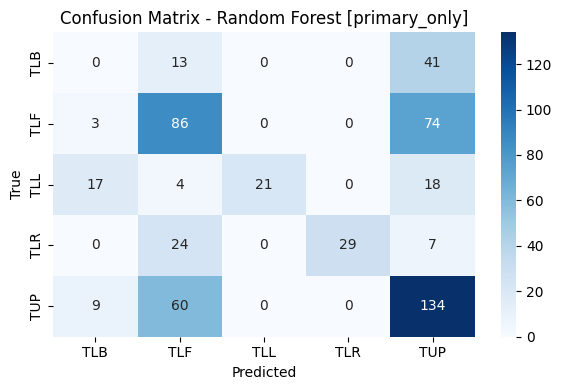


Gradient Boosting [primary_only]
Accuracy : 0.5889
Macro F1 : 0.5875

              precision    recall  f1-score   support

         TLB       0.04      0.02      0.03        54
         TLF       0.53      0.50      0.51       163
         TLL       0.92      0.75      0.83        60
         TLR       1.00      1.00      1.00        60
         TUP       0.51      0.65      0.57       203

    accuracy                           0.59       540
   macro avg       0.60      0.58      0.59       540
weighted avg       0.57      0.59      0.58       540



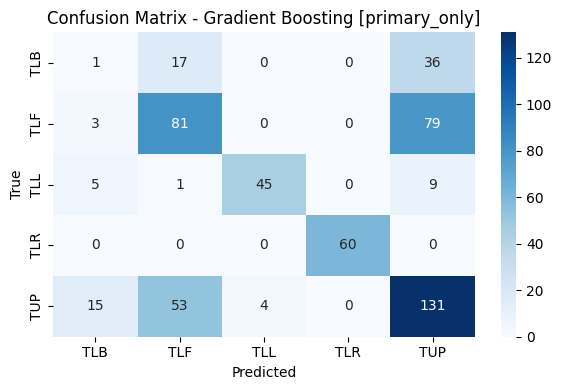


SVM [primary_only]
Accuracy : 0.4074
Macro F1 : 0.3355

              precision    recall  f1-score   support

         TLB       0.00      0.00      0.00        54
         TLF       0.34      0.48      0.40       163
         TLL       1.00      0.25      0.40        60
         TLR       0.74      0.23      0.35        60
         TUP       0.49      0.55      0.52       203

    accuracy                           0.41       540
   macro avg       0.51      0.30      0.34       540
weighted avg       0.48      0.41      0.40       540



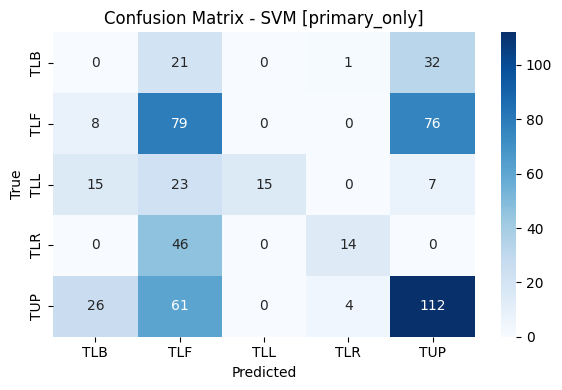


KNN [primary_only]
Accuracy : 0.4685
Macro F1 : 0.4143

              precision    recall  f1-score   support

         TLB       0.17      0.13      0.15        54
         TLF       0.46      0.72      0.57       163
         TLL       0.91      0.17      0.28        60
         TLR       1.00      0.47      0.64        60
         TUP       0.44      0.44      0.44       203

    accuracy                           0.47       540
   macro avg       0.60      0.39      0.41       540
weighted avg       0.53      0.47      0.45       540



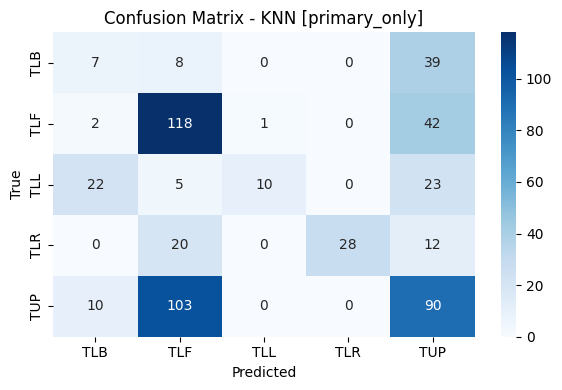


MLP [primary_only]
Accuracy : 0.4056
Macro F1 : 0.3545

              precision    recall  f1-score   support

         TLB       0.05      0.09      0.07        54
         TLF       0.42      0.41      0.42       163
         TLL       0.86      0.10      0.18        60
         TLR       0.93      0.45      0.61        60
         TUP       0.45      0.56      0.50       203

    accuracy                           0.41       540
   macro avg       0.54      0.32      0.35       540
weighted avg       0.50      0.41      0.41       540



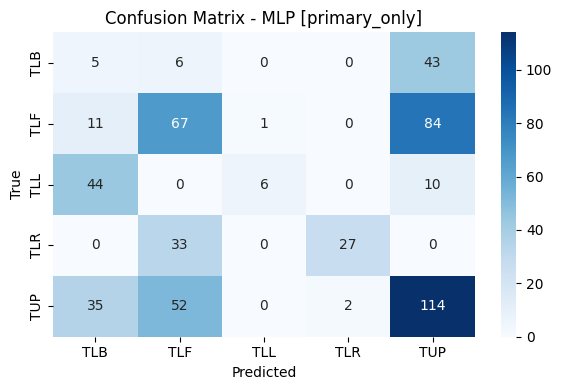


################################################################################
FEATURE SET: primary_plus_sagittal
################################################################################
Using 9 features
['head_tilt', 'shoulder_slope', 'head_lateral_ratio', 'head_y_ratio', 'head_neck_vertical_angle', 'head_shoulder_alignment', 'upper_body_inclination', 'head_trunk_diff', 'trunk_forward_backward_angle']

Random Forest [primary_plus_sagittal]
Accuracy : 0.9037
Macro F1 : 0.8659

              precision    recall  f1-score   support

         TLB       0.92      0.61      0.73        54
         TLF       0.88      1.00      0.93       163
         TLL       1.00      0.63      0.78        60
         TLR       1.00      0.92      0.96        60
         TUP       0.88      0.98      0.93       203

    accuracy                           0.90       540
   macro avg       0.94      0.83      0.87       540
weighted avg       0.91      0.90      0.90       540



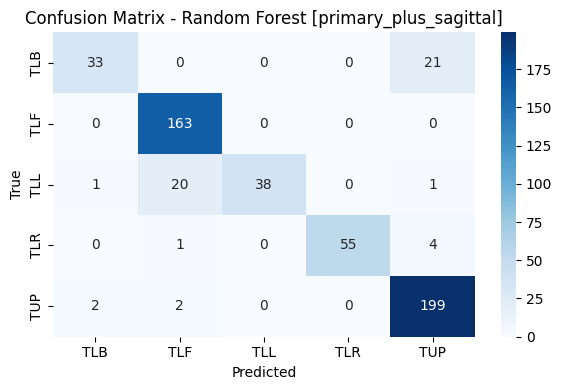


Gradient Boosting [primary_plus_sagittal]
Accuracy : 0.8759
Macro F1 : 0.7720

              precision    recall  f1-score   support

         TLB       0.67      0.96      0.79        54
         TLF       0.91      1.00      0.95       163
         TLL       1.00      0.73      0.85        60
         TLR       1.00      0.20      0.33        60
         TUP       0.89      1.00      0.94       203

    accuracy                           0.88       540
   macro avg       0.89      0.78      0.77       540
weighted avg       0.90      0.88      0.85       540



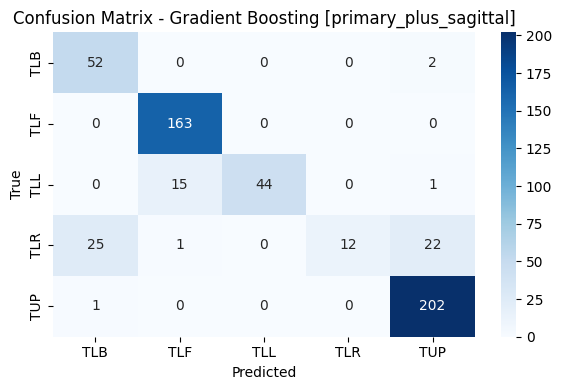


SVM [primary_plus_sagittal]
Accuracy : 0.6444
Macro F1 : 0.5191

              precision    recall  f1-score   support

         TLB       0.55      0.30      0.39        54
         TLF       0.55      0.84      0.67       163
         TLL       1.00      0.25      0.40        60
         TLR       0.79      0.25      0.38        60
         TUP       0.72      0.81      0.76       203

    accuracy                           0.64       540
   macro avg       0.72      0.49      0.52       540
weighted avg       0.69      0.64      0.61       540



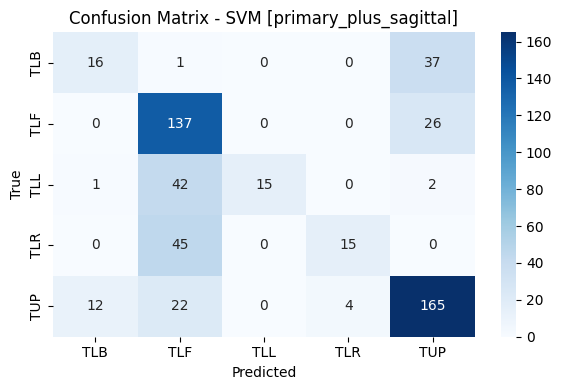


KNN [primary_plus_sagittal]
Accuracy : 0.6500
Macro F1 : 0.5513

              precision    recall  f1-score   support

         TLB       0.44      0.15      0.22        54
         TLF       0.65      0.82      0.73       163
         TLL       0.88      0.25      0.39        60
         TLR       1.00      0.58      0.74        60
         TUP       0.60      0.78      0.68       203

    accuracy                           0.65       540
   macro avg       0.72      0.52      0.55       540
weighted avg       0.68      0.65      0.62       540



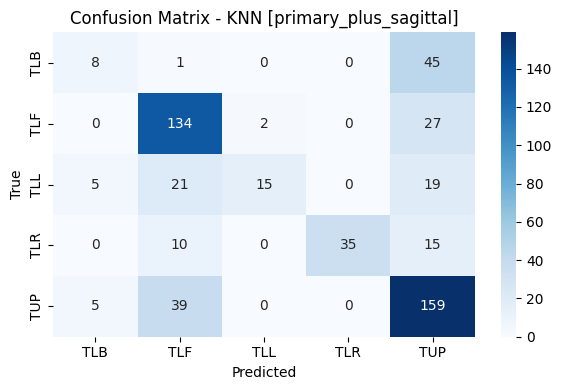


MLP [primary_plus_sagittal]
Accuracy : 0.6259
Macro F1 : 0.4342

              precision    recall  f1-score   support

         TLB       0.11      0.04      0.05        54
         TLF       0.64      0.90      0.75       163
         TLL       1.00      0.07      0.12        60
         TLR       0.96      0.38      0.55        60
         TUP       0.61      0.80      0.69       203

    accuracy                           0.63       540
   macro avg       0.66      0.44      0.43       540
weighted avg       0.65      0.63      0.57       540



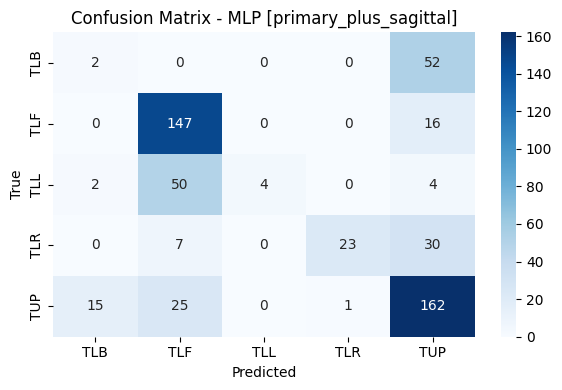

In [28]:
for feature_set_name, feature_cols in FEATURE_SETS.items():
    print("\n" + "#" * 80)
    print(f"FEATURE SET: {feature_set_name}")
    print("#" * 80)

    X = df_clean[feature_cols].copy().values
    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y_enc[train_idx]
    y_test = y_enc[test_idx]

    print(f"Using {len(feature_cols)} features")
    print(feature_cols)

    models = build_models()

    for model_name, model in models.items():
        full_name = f"{model_name} [{feature_set_name}]"

        result = evaluate(
            name=full_name,
            model=model,
            X_tr=X_train,
            y_tr=y_train,
            X_te=X_test,
            y_te=y_test,
            label_encoder=label_encoder
        )

        results.append({
            "feature_set": feature_set_name,
            "model_name": model_name,
            "full_name": full_name,
            "n_features": len(feature_cols),
            "accuracy": result["accuracy"],
            "macro_f1": result["macro_f1"],
        })

        trained_models.append({
            "full_name": full_name,
            "model": result["model"],
            "feature_cols": feature_cols,
        })

## Final ranking

In [29]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=["macro_f1", "accuracy"],
    ascending=False
).reset_index(drop=True)

print("FINAL RANKING:")
print(results_df[["full_name", "n_features", "accuracy", "macro_f1"]])

FINAL RANKING:
                                   full_name  n_features  accuracy  macro_f1
0      Random Forest [primary_plus_sagittal]           9  0.903704  0.865874
1  Gradient Boosting [primary_plus_sagittal]           9  0.875926  0.772023
2           Gradient Boosting [primary_only]           8  0.588889  0.587533
3                KNN [primary_plus_sagittal]           9  0.650000  0.551285
4                SVM [primary_plus_sagittal]           9  0.644444  0.519141
5               Random Forest [primary_only]           8  0.500000  0.444695
6                MLP [primary_plus_sagittal]           9  0.625926  0.434241
7                         KNN [primary_only]           8  0.468519  0.414293
8                         MLP [primary_only]           8  0.405556  0.354522
9                         SVM [primary_only]           8  0.407407  0.335479


## Best model selection

In [30]:
results_sagittal = results_df[
    results_df["feature_set"] == "primary_plus_sagittal"
].copy().sort_values(by=["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)

if results_sagittal.empty:
    raise ValueError("Nessun modello primary_plus_sagittal trovato.")

best_row        = results_sagittal.iloc[0]
best_model_name = best_row["full_name"]

best_model_entry  = next(m for m in trained_models if m["full_name"] == best_model_name)
best_model        = best_model_entry["model"]
best_feature_cols = best_model_entry["feature_cols"]

print("[DEPLOY MODE: PRIMARY + SAGITTAL]")
print(f"Best model:    {best_model_name}")
print(f"Best accuracy: {best_row['accuracy']:.4f}")
print(f"Best macro F1: {best_row['macro_f1']:.4f}")
print(f"Features ({len(best_feature_cols)}): {best_feature_cols}")

print("\nTop 3 sagittal models:")
print(results_sagittal.head(3)[["full_name", "accuracy", "macro_f1"]])

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
with open("best_feature_columns.pkl", "wb") as f:
    pickle.dump(best_feature_cols, f)

print("\nSaved: best_model.pkl | label_encoder.pkl | best_feature_columns.pkl")

[DEPLOY MODE: PRIMARY + SAGITTAL]
Best model:    Random Forest [primary_plus_sagittal]
Best accuracy: 0.9037
Best macro F1: 0.8659
Features (9): ['head_tilt', 'shoulder_slope', 'head_lateral_ratio', 'head_y_ratio', 'head_neck_vertical_angle', 'head_shoulder_alignment', 'upper_body_inclination', 'head_trunk_diff', 'trunk_forward_backward_angle']

Top 3 sagittal models:
                                   full_name  accuracy  macro_f1
0      Random Forest [primary_plus_sagittal]  0.903704  0.865874
1  Gradient Boosting [primary_plus_sagittal]  0.875926  0.772023
2                KNN [primary_plus_sagittal]  0.650000  0.551285

Saved: best_model.pkl | label_encoder.pkl | best_feature_columns.pkl


# 4. Selezione modello finale e inferenza real-time con MediaPipe

In questa parte del notebook completiamo due step fondamentali della pipeline:

1. **Confronto finale dei modelli su group split**
2. **Caricamento del modello migliore per l'inferenza real-time da webcam**

L'obiettivo è usare in tempo reale lo stesso approccio del training:
- estrazione landmark con **MediaPipe Pose**
- costruzione delle feature posturali
- normalizzazione con lo scaler salvato
- predizione della postura tramite il modello migliore
- visualizzazione del risultato sul frame

## Import librerie per webcam e inferenza

In [31]:
import os
import cv2
import json
import pickle
import collections
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import time
from datetime import datetime
from IPython.display import display

## Caricamento del modello salvato

In [32]:
required_files = ["best_model.pkl", "label_encoder.pkl", "best_feature_columns.pkl"]
missing_files  = [f for f in required_files if not os.path.exists(f)]
if missing_files:
    raise FileNotFoundError(f"File mancanti: {missing_files}")
 
with open("best_model.pkl", "rb") as f:
    best_model = pickle.load(f)
with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)
with open("best_feature_columns.pkl", "rb") as f:
    BEST_FEATURE_COLUMNS = pickle.load(f)
 
print("Modello:  ", type(best_model).__name__)
print("Classi:   ", list(label_encoder.classes_))
print("Features: ", BEST_FEATURE_COLUMNS)

Modello:   Pipeline
Classi:    ['TLB', 'TLF', 'TLL', 'TLR', 'TUP']
Features:  ['head_tilt', 'shoulder_slope', 'head_lateral_ratio', 'head_y_ratio', 'head_neck_vertical_angle', 'head_shoulder_alignment', 'upper_body_inclination', 'head_trunk_diff', 'trunk_forward_backward_angle']


## Inizializzazione di MediaPipe Pose

In [33]:
mp_pose    = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
 
if "pose" in dir() and pose is not None:
    try:
        pose.close()
    except Exception:
        pass
 
pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    smooth_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)
print("MediaPipe Pose inizializzato.")

MediaPipe Pose inizializzato.


I0000 00:00:1774178021.639680  463198 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 88.1), renderer: Apple M3


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774178021.724699  464066 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774178021.730125  464068 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## Connessione iPhone

In [34]:
CAMERA_INDEX = 1

cap = cv2.VideoCapture(CAMERA_INDEX)
# prova una risoluzione più leggera
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

actual_w = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
actual_h = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)

print(f"Risoluzione acquisita: {actual_w}x{actual_h}")

2026-03-22 12:13:46.036 Python[8972:463198] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


Risoluzione acquisita: 1280.0x720.0


## Parametri principali della pipeline

In [35]:
CONF_THRESHOLD     = 0.5
SMOOTH_WINDOW      = 10
CALIBRATION_FRAMES = 30
POSTURE_FRAMES     = 15
REQUIRED_IDX       = [0, 11, 12]   # naso + spalle obbligatori
 
z_buffer = collections.deque(maxlen=SMOOTH_WINDOW)
 
# Feature names — unica definizione autorevole
FEATURE_NAMES = [
    "head_tilt",
    "shoulder_slope",
    "head_lateral_ratio",
    "head_y_ratio",
    "head_neck_vertical_angle",
    "head_shoulder_alignment",
    "upper_body_inclination",
    "head_trunk_diff",
    "trunk_forward_backward_angle",  # fix -T_y
]
PRIMARY_FEATURES = FEATURE_NAMES[:8]
SUPPORT_FEATURES = FEATURE_NAMES[8:]
 
# Label colors e descrizioni
LABEL_COLORS = {
    "TUP": (0, 220, 0),
    "TLL": (255, 100, 0),
    "TLR": (255, 100, 0),
    "TLF": (0, 180, 255),
    "TLB": (180, 0, 255),
}
LABEL_DESC = {
    "TUP": "Postura corretta",
    "TLL": "Inclinazione laterale sx",
    "TLR": "Inclinazione laterale dx",
    "TLF": "Forward head / slumping",
    "TLB": "Backward posture",
}
 
# Verifica allineamento feature
if set(FEATURE_NAMES) != set(BEST_FEATURE_COLUMNS):
    print("⚠  FEATURE_NAMES e BEST_FEATURE_COLUMNS non coincidono!")
    print("   Mancanti:", set(BEST_FEATURE_COLUMNS) - set(FEATURE_NAMES))
    print("   Extra:   ", set(FEATURE_NAMES) - set(BEST_FEATURE_COLUMNS))
else:
    print(f"✓  Feature allineate — {len(FEATURE_NAMES)} feature.")

✓  Feature allineate — 9 feature.


## Funzioni di preprocessing e feature extraction

In [36]:
def capture_frames_batch(n_frames):
    frames = []
    for _ in range(n_frames):
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
        time.sleep(0.12)
    return frames
 
 
def landmarks_to_array(results):
    lm = results.pose_landmarks.landmark
    return np.array([[l.x, l.y, l.z] for l in lm], dtype=float)
 
 
def smooth_z(lm_array):
    z_buffer.append(lm_array[:, 2].copy())
    smoothed = lm_array.copy()
    smoothed[:, 2] = np.mean(z_buffer, axis=0)
    return smoothed
 
 
def check_visibility(results):
    lm = results.pose_landmarks.landmark
    shoulders_ok = (lm[11].visibility >= CONF_THRESHOLD and
                    lm[12].visibility >= CONF_THRESHOLD)
    head_ok = ((lm[2].visibility >= CONF_THRESHOLD and
                lm[5].visibility >= CONF_THRESHOLD) or
               (lm[7].visibility >= CONF_THRESHOLD and
                lm[8].visibility >= CONF_THRESHOLD) or
               lm[0].visibility >= CONF_THRESHOLD)
    return shoulders_ok and head_ok
 
 
def extract_features_from_array(lm_array, results):
    lm = results.pose_landmarks.landmark
 
    features_dict, control_dict = extract_features_with_control(
        nose=lm_array[0],
        l_eye=lm_array[2],  r_eye=lm_array[5],
        l_ear=lm_array[7],  r_ear=lm_array[8],
        l_shoulder=lm_array[11], r_shoulder=lm_array[12],
        l_hip=lm_array[23],      r_hip=lm_array[24],
        nose_vis=lm[0].visibility,
        l_eye_vis=lm[2].visibility,  r_eye_vis=lm[5].visibility,
        l_ear_vis=lm[7].visibility,  r_ear_vis=lm[8].visibility,
        l_shoulder_vis=lm[11].visibility, r_shoulder_vis=lm[12].visibility,
        l_hip_vis=lm[23].visibility,      r_hip_vis=lm[24].visibility,
    )
 
    # Flag extra per il debug overlay
    control_dict["shoulders_reliable"] = (lm[11].visibility >= CONF_THRESHOLD and
                                           lm[12].visibility >= CONF_THRESHOLD)
    control_dict["head_reliable"] = (
        (lm[2].visibility >= CONF_THRESHOLD and lm[5].visibility >= CONF_THRESHOLD) or
        (lm[7].visibility >= CONF_THRESHOLD and lm[8].visibility >= CONF_THRESHOLD) or
        lm[0].visibility >= CONF_THRESHOLD
    )
    control_dict["hips_reliable"] = (lm[23].visibility >= CONF_THRESHOLD and
                                      lm[24].visibility >= CONF_THRESHOLD)
    control_dict["trunk_support_reliable"] = control_dict["hips_reliable"]
 
    return features_dict, control_dict
 
 
def feature_dict_to_model_vector(feature_dict, feature_columns):
    return np.array([feature_dict.get(f, np.nan) for f in feature_columns], dtype=float)

## Funzioni predizione e classificazione

### Costanti e baseline helpers

_safe_std : durante la calibrazione l'utente potrebbe stare quasi perfettamente fermo, generando una std bassissima o zero. Questa funzione garantisce che ogni feature abbia sempre una "sensibilità minima" diversa per tipo: ad esempio head_lateral_ratio è già molto sensibile (floor 0.08), mentre upper_body_inclination richiede scostamenti più grandi (floor 4.0) prima di suonare l'allarme.

_clamped_delta : risponde alla domanda: "quanto si è spostata questa feature rispetto alla postura neutra calibrata?" — in unità di deviazioni standard. Il clamp a ±4 evita che un valore estremo (es. testa completamente girata) produca uno score enorme e destabilizzi la classificazione.

get_baseline_value : legge dalla baseline calibrata il valore di riferimento (di default la mediana) per una feature. Usata ogni volta che dobbiamo confrontare la postura attuale con quella neutra dell'utente.

get_baseline_std : legge dalla baseline la variabilità naturale dell'utente per una feature. Serve a capire quanto deve spostarsi quella feature per essere considerata "anomala" rispetto a come si muove normalmente quella persona.

In [37]:
EPS_STD = 1e-3

STD_FLOOR = {
    "head_tilt":                    1.0,
    "shoulder_slope":               1.0,
    "head_lateral_ratio":           0.08,
    "head_y_ratio":                 0.04,
    "head_neck_vertical_angle":     1.0,
    "head_shoulder_alignment":      1.5,
    "upper_body_inclination":       4.0,
    "head_trunk_diff":              1.5,
    "trunk_forward_backward_angle": 3.0,
}
DELTA_CLAMP = 4.0

def _safe_std(std, feature_name):
    floor = STD_FLOOR.get(feature_name, 0.001)
    return max(std, floor) if (np.isfinite(std) and std > 0) else floor

def _clamped_delta(val, baseline, std):
    if not (np.isfinite(val) and np.isfinite(baseline) and
            np.isfinite(std) and std > EPS_STD):
        return np.nan
    return float(np.clip((val - baseline) / std, -DELTA_CLAMP, DELTA_CLAMP))


def get_baseline_value(baseline_stats, name, field="median"):
    if baseline_stats is None or name not in baseline_stats:
        return np.nan
    return baseline_stats[name].get(field, np.nan)


def get_baseline_std(baseline_stats, name):
    if baseline_stats is None or name not in baseline_stats:
        return np.nan
    return baseline_stats[name].get("std", np.nan)

### Predict and score helpers

predict : passa il vettore di feature al modello ML addestrato e restituisce la classe predetta (es. "TLF"), la sua probabilità, e tutte le probabilità per classe. È il punto in cui il modello "vota" la postura attuale.

_compute_lateral_score : misura quanto l'utente si sta inclinando lateralmente rispetto alla sua postura neutra calibrata, combinando due segnali: lo spostamento orizzontale della testa (head_lateral_ratio, peso maggiore) e l'inclinazione del busto (upper_body_inclination, peso minore). Un valore positivo indica inclinazione verso sinistra (TLL), negativo verso destra (TLR).

_compute_sagittal_score : misura quanto l'utente si sta inclinando in avanti o indietro rispetto alla sua postura neutra calibrata, combinando tre segnali: l'inclinazione del tronco in profondità (trunk_forward_backward_angle, peso principale), l'altezza relativa della testa rispetto alle spalle (head_y_ratio), e l'angolo testa-collo (head_neck_vertical_angle, usato solo come rinforzo se concorda con gli altri due). Un valore negativo indica postura in avanti (TLF), positivo all'indietro (TLB).

In [38]:
def predict(features_vector, model, label_encoder):
    fv    = np.asarray(features_vector, dtype=float).reshape(1, -1)
    probs = model.predict_proba(fv)[0]
    idx   = int(np.argmax(probs))
    return label_encoder.inverse_transform([idx])[0], float(probs[idx]), probs


def _compute_lateral_score(feat, baseline_stats):
    pairs = [
        ("head_lateral_ratio",     2.5),
        ("upper_body_inclination", 1.5),
    ]
    components = []
    for name, w in pairs:
        val = feat.get(name, np.nan)
        if not np.isfinite(val):
            continue
        b   = get_baseline_value(baseline_stats, name)
        std = _safe_std(get_baseline_std(baseline_stats, name), name)
        d   = _clamped_delta(val, b, std)
        if np.isfinite(d):
            components.append((d, w))
    if not components:
        return np.nan
    total_w = sum(w for _, w in components)
    return sum(v * w for v, w in components) / total_w


def _compute_sagittal_score(feat, baseline_stats):
    """
    Score sagittale:
      - trunk_forward_backward_angle (peso 3.0) — segnale principale
      - head_y_ratio (peso 1.5)                 — segnale secondario
      - head_neck_vertical_angle (peso 1.0)     — rinforzo solo se concorda con hyr
    Convenzione: negativo = TLF (forward), positivo = TLB (backward).
    """
    components = []

    tfb = feat.get("trunk_forward_backward_angle", np.nan)
    if np.isfinite(tfb):
        b   = get_baseline_value(baseline_stats, "trunk_forward_backward_angle")
        std = _safe_std(get_baseline_std(baseline_stats, "trunk_forward_backward_angle"),
                        "trunk_forward_backward_angle")
        d   = _clamped_delta(tfb, b, std)
        if np.isfinite(d):
            components.append((d, 3.0))

    hyr = feat.get("head_y_ratio", np.nan)
    if np.isfinite(hyr):
        b   = get_baseline_value(baseline_stats, "head_y_ratio")
        std = _safe_std(get_baseline_std(baseline_stats, "head_y_ratio"), "head_y_ratio")
        d   = _clamped_delta(hyr, b, std)
        if np.isfinite(d):
            components.append((-d, 1.5))

    hnv = feat.get("head_neck_vertical_angle", np.nan)
    if np.isfinite(hnv) and hnv > 3.0 and np.isfinite(hyr):
        b   = get_baseline_value(baseline_stats, "head_neck_vertical_angle")
        std = _safe_std(get_baseline_std(baseline_stats, "head_neck_vertical_angle"),
                        "head_neck_vertical_angle")
        d   = _clamped_delta(hnv, b, std)
        if np.isfinite(d):
            hyr_d = _clamped_delta(
                hyr,
                get_baseline_value(baseline_stats, "head_y_ratio"),
                _safe_std(get_baseline_std(baseline_stats, "head_y_ratio"), "head_y_ratio")
            )
            if np.isfinite(hyr_d) and d * hyr_d > 0:
                components.append((-d, 1.0))

    if not components:
        return np.nan
    total_w = sum(w for _, w in components)
    return sum(v * w for v, w in components) / total_w

### Classify posture

classify_posture : è il cuore del sistema di classificazione. Prende la predizione del modello ML e la "corregge" o "conferma" usando regole geometriche basate sulla baseline calibrata. L'idea è che il ML da solo può sbagliare in casi limite, quindi le regole geometriche fungono da guardia.

1. Guard laterale estremo (lat_abs > 3.5)
Se la testa è spostata lateralmente in modo molto vistoso, la regola geometrica sovrascrive il ML senza nemmeno guardare la sua confidenza. È un caso così evidente che non vale la pena fidarsi del modello.
2. ML ad alta confidenza (confidence >= 0.85)
Se il modello è molto sicuro della sua predizione, non si interviene. Le regole geometriche entrano solo quando il ML è incerto.
3. TLR geometrico (head_tilt < -30° e head_shoulder_alignment < -15°)
Rileva il caso specifico in cui l'utente è ripreso di lato e la testa appare ruotata/inclinata in modo estremo — situazione in cui il ML tende a confondersi ma la geometria è chiara.
4. TLF geometrico (hnv > baseline + 8° e hyr < baseline - 0.08)
Rileva la testa abbassata in avanti: l'angolo collo-verticale è aumentato rispetto alla baseline e la testa è scesa rispetto alle spalle. Questo blocco non scatta se c'è anche una forte inclinazione laterale (per evitare falsi TLF quando l'utente è semplicemente inclinato di lato).
5. Nessun segnale (lat_sig = False e sag_sig = False)
Se né il segnale laterale né quello sagittale superano la soglia, la postura viene considerata corretta (TUP) indipendentemente da cosa dice il ML.
6. Laterale forte
Se il segnale laterale supera chiaramente la soglia, si restituisce TLL o TLR in base al segno dello score.
7. Laterale domina sul sagittale
Se entrambi i segnali sono presenti ma quello laterale è almeno 1.1x più forte di quello sagittale, vince il laterale. Evita che una piccola componente sagittale cambi la classificazione quando l'inclinazione laterale è il problema principale.
8. Solo sagittale
Se c'è solo segnale sagittale senza componente laterale rilevante, si restituisce TLF (in avanti) o TLB (all'indietro) in base al segno.
9. Caso ambiguo
Se nessuna regola ha prodotto una risposta chiara, si torna alla predizione del ML come fallback.

In [39]:
def classify_posture(label_ml, confidence, feature_dict, baseline_stats):
    LAT_ABS_THR_POS = 2.0
    LAT_ABS_THR_NEG = 2.0
    DOMINANCE_RATIO = 1.1
    ML_TRUST_THR    = 0.85

    # Soglia sagittale dinamica
    trunk_fba = feature_dict.get("trunk_forward_backward_angle")
    trunk_fba_available = trunk_fba is not None and np.isfinite(trunk_fba)
    SAG_ABS_THR = 1.6 if trunk_fba_available else 2.2  # era 1.4 — FIX problema C (TUP->TLB rumoroso)

    lat_score = _compute_lateral_score(feature_dict, baseline_stats)
    sag_score = _compute_sagittal_score(feature_dict, baseline_stats)
    lat_abs   = abs(lat_score) if np.isfinite(lat_score) else 0.0
    sag_abs   = abs(sag_score) if np.isfinite(sag_score) else 0.0

    # Soglia sagittale adattiva per posture miste lat+sag — FIX problema B (TLR<->TLB)
    if np.isfinite(lat_score) and lat_abs > 1.5:
        SAG_ABS_THR = max(SAG_ABS_THR, 2.0)

    lat_thr = LAT_ABS_THR_NEG if (np.isfinite(lat_score) and lat_score < 0) \
              else LAT_ABS_THR_POS
    lat_sig = lat_abs > lat_thr
    sag_sig = sag_abs > SAG_ABS_THR

    info = {
        "lateral_score":   round(float(lat_score), 4) if np.isfinite(lat_score) else None,
        "sagittal_score":  round(float(sag_score), 4) if np.isfinite(sag_score) else None,
        "rule_triggered":  False,
        "confidence_tier": "high",
        "reason":          [],
    }

    # ── Guard laterale estremo: sovrascrive ML anche ad alta confidenza ──
    if np.isfinite(lat_score) and lat_abs > 3.5:
        info["rule_triggered"] = True
        info["reason"].append(f"laterale estremo ({lat_abs:.2f}) — ML ignorato")
        return ("TLL" if lat_score > 0 else "TLR"), info

    # ── ML ad alta confidenza: non intervenire ──
    if confidence >= ML_TRUST_THR:
        info["reason"].append(f"ML alta confidenza ({confidence:.1%})")
        return label_ml, info

    # ── TLR geometrico: head_tilt negativo estremo da vista laterale ──
    if (np.isfinite(feature_dict.get("head_tilt", np.nan)) and
            np.isfinite(feature_dict.get("head_shoulder_alignment", np.nan))):
        ht  = feature_dict["head_tilt"]
        hsa = feature_dict["head_shoulder_alignment"]
        if ht < -30.0 and hsa < -15.0:
            info["rule_triggered"] = True
            info["reason"].append(f"TLR geometrico (head_tilt={ht:.1f}°, hsa={hsa:.1f}°)")
            return "TLR", info

    # ── TLF geometrico: testa abbassata in avanti ──
    if (np.isfinite(feature_dict.get("head_neck_vertical_angle", np.nan)) and
            np.isfinite(feature_dict.get("head_y_ratio", np.nan))):
        hnv   = feature_dict["head_neck_vertical_angle"]
        hyr   = feature_dict["head_y_ratio"]
        b_hnv = baseline_stats["head_neck_vertical_angle"]["median"] \
                if baseline_stats else np.nan
        b_hyr = baseline_stats["head_y_ratio"]["median"] \
                if baseline_stats else np.nan
        # FIX problema A (TLF<->TLL): quando sag è clamped la TLF è certa,
        # serve lat > 3.0 per scavalcarla invece di 2.5
        lat_limit = 3.0 if (sag_abs >= DELTA_CLAMP * 0.95) else 1.82
        if (np.isfinite(b_hnv) and np.isfinite(b_hyr) and
                hnv > b_hnv + 8.0 and hyr < b_hyr - 0.08 and
                lat_abs < lat_limit):
            info["rule_triggered"] = True
            info["reason"].append(f"TLF geometrico (hnv={hnv:.1f}°, hyr={hyr:.3f})")
            return "TLF", info

    # ── Nessun segnale geometrico: postura neutra ──
    if not lat_sig and not sag_sig:
        info["rule_triggered"] = True
        info["reason"].append("segnali geometrici deboli → TUP")
        return "TUP", info

    # ── Laterale molto forte (usa soglia asimmetrica) ──
    if lat_sig and lat_abs >= lat_thr:
        info["rule_triggered"] = True
        info["reason"].append(f"laterale forte ({lat_abs:.2f})")
        return ("TLL" if lat_score > 0 else "TLR"), info

    # ── Laterale domina sul sagittale ──
    if lat_sig and (not sag_sig or lat_abs >= sag_abs * DOMINANCE_RATIO):
        info["rule_triggered"] = True
        info["reason"].append(f"laterale domina ({lat_abs:.2f} vs {sag_abs:.2f})")
        return ("TLL" if lat_score > 0 else "TLR"), info

    # ── Solo sagittale ──
    if sag_sig and not lat_sig:
        info["rule_triggered"] = True
        info["confidence_tier"] = "medium"
        info["reason"].append(f"sagittale ({sag_abs:.2f})")
        return ("TLF" if sag_score < 0 else "TLB"), info

    # ── Caso ambiguo: usa ML ──
    info["reason"].append(f"ambiguo → ML: {label_ml} ({confidence:.1%})")
    return label_ml, info

## Funzioni di disegno per il debug overlay

In [40]:
GREEN  = (0, 220, 0)
YELLOW = (0, 220, 255)
ORANGE = (0, 140, 255)
RED    = (0, 0, 255)
WHITE  = (255, 255, 255)
BLACK  = (0, 0, 0)
CYAN   = (255, 220, 0)
GRAY   = (180, 180, 180)
 
 
def draw_landmark_point(frame, lm, idx, color, radius=6):
    h, w = frame.shape[:2]
    x = int(lm[idx].x * w)
    y = int(lm[idx].y * h)
    cv2.circle(frame, (x, y), radius, color, -1)
    cv2.circle(frame, (x, y), radius + 2, WHITE, 1)
    return (x, y)
 
 
def draw_line_between(frame, p1, p2, color, thickness=2):
    cv2.line(frame, p1, p2, color, thickness)
 
 
def put_text_pro(frame, text, pos, scale=0.7, color=WHITE, thickness=1):
    cv2.putText(frame, text, pos, cv2.FONT_HERSHEY_DUPLEX,
                scale, BLACK, thickness + 2, cv2.LINE_AA)
    cv2.putText(frame, text, pos, cv2.FONT_HERSHEY_DUPLEX,
                scale, color, thickness, cv2.LINE_AA)
 
 
def draw_debug_overlay(frame, lm, feature_dict, label, confidence,
                        confidence_tier="high", rule_info=None):
    h, w   = frame.shape[:2]
    color  = LABEL_COLORS.get(label, WHITE)
    desc   = LABEL_DESC.get(label, label)
 
    # Barra superiore
    overlay = frame.copy()
    cv2.rectangle(overlay, (0, 0), (w, 80), (10, 10, 10), -1)
    cv2.addWeighted(overlay, 0.75, frame, 0.25, 0, frame)
 
    put_text_pro(frame, f"{label}  {desc}", (14, 30),
                 scale=0.85, color=color, thickness=2)
    put_text_pro(frame, f"Conf: {confidence:.1%}", (14, 56),
                 scale=0.55, color=GRAY, thickness=1)
 
    if rule_info and rule_info.get("reason"):
        reason_str = " | ".join(rule_info["reason"])[:60]
        put_text_pro(frame, reason_str, (14, 74),
                     scale=0.38, color=YELLOW, thickness=1)
 
    # Barra laterale verde/rossa
    bar_color = GREEN if label == "TUP" else RED
    cv2.rectangle(frame, (w - 10, 0), (w, h), bar_color, -1)
 
    # Landmark
    p_leye = draw_landmark_point(frame, lm, 2, CYAN)
    p_reye = draw_landmark_point(frame, lm, 5, CYAN)
    draw_line_between(frame, p_leye, p_reye, CYAN, 2)
    draw_landmark_point(frame, lm, 7, (180, 180, 0))
    draw_landmark_point(frame, lm, 8, (180, 180, 0))
    p_nose = draw_landmark_point(frame, lm, 0, WHITE, 5)
    p_lsho = draw_landmark_point(frame, lm, 11, GREEN)
    p_rsho = draw_landmark_point(frame, lm, 12, GREEN)
    draw_line_between(frame, p_lsho, p_rsho, GREEN, 2)
 
    mid_sho = ((p_lsho[0] + p_rsho[0]) // 2, (p_lsho[1] + p_rsho[1]) // 2)
    cv2.circle(frame, mid_sho, 5, WHITE, -1)
    draw_line_between(frame, p_nose, mid_sho, ORANGE, 2)
 
    mid_eye = ((p_leye[0] + p_reye[0]) // 2, (p_leye[1] + p_reye[1]) // 2)
    draw_line_between(frame, mid_eye, mid_sho, YELLOW, 2)
 
    # Box correzione
    if label != "TUP":
        bx, by = w // 2, h // 2
        ov2 = frame.copy()
        cv2.rectangle(ov2, (bx - 160, by - 35), (bx + 160, by + 35), (10, 10, 10), -1)
        cv2.addWeighted(ov2, 0.8, frame, 0.2, 0, frame)
        cv2.rectangle(frame, (bx - 160, by - 35), (bx + 160, by + 35), color, 2)
        put_text_pro(frame, f"CORREGGI: {desc}",
                     (bx - 148, by + 10), scale=0.6, color=color, thickness=1)
 
    return frame

## Calibrazione

In [41]:
import collections, time, json
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# ════════════════════════════════════════════════════════════════════
# PARAMETRI
# ════════════════════════════════════════════════════════════════════
CALIBRATION_FRAMES = 30
CLASSIFICATION_FPS = 4
ALERT_SECONDS      = 5
ALERT_BUFFER_SIZE  = int(ALERT_SECONDS * CLASSIFICATION_FPS)  # 20 campioni
ALERT_BAD_RATIO    = 0.70
WINDOW_NAME        = "Posture Monitor"
TEST_DIR           = "Test"
os.makedirs(TEST_DIR, exist_ok=True)

# ════════════════════════════════════════════════════════════════════
# FASE 1 — CALIBRAZIONE
# ════════════════════════════════════════════════════════════════════
z_buffer.clear()
baseline_stats = None

print("=" * 60)
print("FASE 1: CALIBRAZIONE")
print("Siediti in postura corretta e tieni la posizione.")
print("=" * 60)
for s in range(5, 0, -1):
    print(f"  Inizio tra {s}...")
    time.sleep(1)

calib_collected = []
raw = capture_frames_batch(CALIBRATION_FRAMES * 2)
for frame in raw:
    if len(calib_collected) >= CALIBRATION_FRAMES:
        break
    try:
        res = pose.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    except Exception:
        continue
    if not res.pose_landmarks or not check_visibility(res):
        continue
    lm_arr = smooth_z(landmarks_to_array(res))
    fd, _  = extract_features_from_array(lm_arr, res)
    mv     = feature_dict_to_model_vector(fd, BEST_FEATURE_COLUMNS)
    if np.all(~np.isfinite(mv)):
        continue
    calib_collected.append(fd)
    print(f"  Frame valido {len(calib_collected)}/{CALIBRATION_FRAMES}")

if len(calib_collected) < CALIBRATION_FRAMES // 2:
    raise RuntimeError("Calibrazione fallita — troppo pochi frame validi.")

baseline_stats = {}
for name in FEATURE_NAMES:
    vals  = np.array([d.get(name, np.nan) for d in calib_collected], dtype=float)
    valid = vals[np.isfinite(vals)]
    if len(valid) == 0:
        baseline_stats[name] = {"median": np.nan, "mean": np.nan, "std": np.nan}
    else:
        baseline_stats[name] = {
            "median": float(np.median(valid)),
            "mean":   float(np.mean(valid)),
            "std":    float(np.std(valid)),
        }

print("\n--- Baseline (mediana ± std) ---")
for name in FEATURE_NAMES:
    m  = baseline_stats[name]["median"]
    s  = baseline_stats[name]["std"]
    ms = f"{m:.4f}" if np.isfinite(m) else "NaN"
    ss = f"{s:.4f}" if np.isfinite(s) else "NaN"
    print(f"  {name:<40} {ms}  ±{ss}")

# ── Controllo qualità baseline ────────────────────────────────────
print("\n--- Controllo qualità baseline ---")
STD_WARN = {
    "head_neck_vertical_angle": 4.0,
    "head_y_ratio":             0.05,
    "trunk_forward_backward_angle": 5.0,
    "head_lateral_ratio":       0.04,
}
qualita_ok = True
for name, soglia in STD_WARN.items():
    s = baseline_stats[name]["std"]
    if np.isfinite(s) and s > soglia:
        print(f"  ⚠  {name}: std={s:.4f} > {soglia} — baseline rumorosa, regole geometriche meno affidabili")
        qualita_ok = False
if qualita_ok:
    print("  ✓ Baseline stabile — puoi procedere con il debug o il loop.")

print("\n✓ Calibrazione completata.")
print("→ Esegui ora Cell 63 (debug) oppure direttamente Cell 65b (loop).")

FASE 1: CALIBRAZIONE
Siediti in postura corretta e tieni la posizione.
  Inizio tra 5...
  Inizio tra 4...
  Inizio tra 3...
  Inizio tra 2...
  Inizio tra 1...
  Frame valido 1/30
  Frame valido 2/30
  Frame valido 3/30
  Frame valido 4/30
  Frame valido 5/30
  Frame valido 6/30
  Frame valido 7/30
  Frame valido 8/30
  Frame valido 9/30
  Frame valido 10/30
  Frame valido 11/30
  Frame valido 12/30
  Frame valido 13/30
  Frame valido 14/30
  Frame valido 15/30
  Frame valido 16/30
  Frame valido 17/30
  Frame valido 18/30
  Frame valido 19/30
  Frame valido 20/30
  Frame valido 21/30
  Frame valido 22/30
  Frame valido 23/30
  Frame valido 24/30
  Frame valido 25/30
  Frame valido 26/30
  Frame valido 27/30
  Frame valido 28/30
  Frame valido 29/30
  Frame valido 30/30

--- Baseline (mediana ± std) ---
  head_tilt                                5.9722  ±1.7394
  shoulder_slope                           0.8387  ±1.2501
  head_lateral_ratio                       -0.1255  ±0.0316
  head

## Debug

Cattura frame...

════════════════════════════════════════════════════════════
§1  VISIBILITY
════════════════════════════════════════════════════════════
  nose            0.999  ✓
  l_eye           0.999  ✓
  r_eye           0.999  ✓
  l_ear           0.998  ✓
  r_ear           0.999  ✓
  l_shoulder      0.999  ✓
  r_shoulder      1.000  ✓
  l_hip           0.990  ✓
  r_hip           0.991  ✓

  → Anche visibili? SÌ

════════════════════════════════════════════════════════════
§2  RELIABILITY FLAGS
════════════════════════════════════════════════════════════
  head_center_source             mid_eye
  head_center_conf               0.9986785054206848
  head_center_z_reliable         True
  mid_shoulder_conf              0.9989473819732666
  mid_shoulder_reliable          True
  upper_z_reliable               True
  trunk_support_reliable         True
  shoulders_reliable             True
  head_reliable                  True
  hips_reliable                  True

═════════════════════

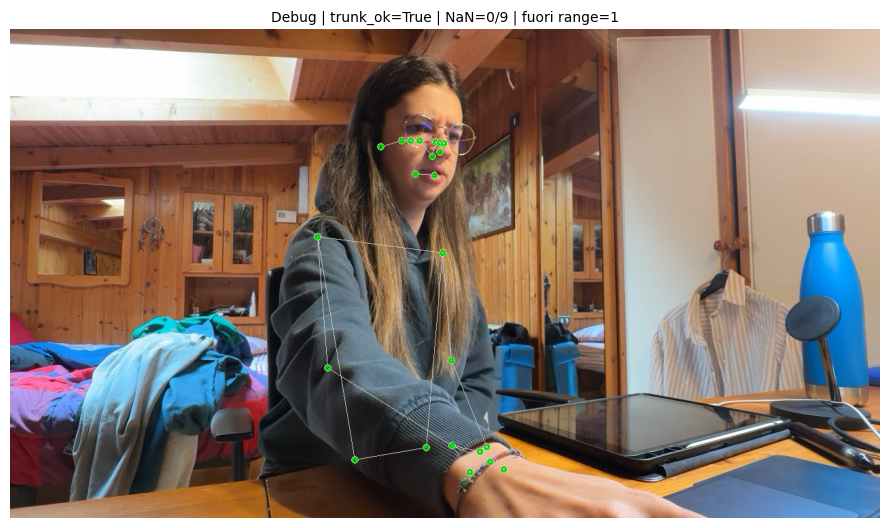


Debug completato.


In [42]:
# Range attesi in postura neutra — inquadratura 30/45°
EXPECTED_RANGES = {
    "head_tilt":                    (-20,  20),
    "shoulder_slope":               (-10,  10),
    "head_lateral_ratio":           (-0.5,  0.2),
    "head_y_ratio":                 (1.0,   2.0),
    "head_neck_vertical_angle":     (0,     25),
    "head_shoulder_alignment":      (-20,   20),
    "upper_body_inclination":       (-20,    5),
    "head_trunk_diff":              (-30,   30),
    "trunk_forward_backward_angle": (-20,   20),
}

print("Cattura frame...")
ret, dbg_frame = cap.read()
if not ret:
    raise RuntimeError("cap.read() fallito.")

dbg_results = pose.process(cv2.cvtColor(dbg_frame, cv2.COLOR_BGR2RGB))
if not dbg_results.pose_landmarks:
    raise RuntimeError("Nessun landmark rilevato.")

dbg_lm        = dbg_results.pose_landmarks.landmark
dbg_lm_array  = landmarks_to_array(dbg_results)
dbg_lm_smooth = smooth_z(dbg_lm_array)
dbg_feat, dbg_ctrl = extract_features_from_array(dbg_lm_smooth, dbg_results)

# §1 Visibility
LANDMARK_MAP = {0:"nose", 2:"l_eye", 5:"r_eye", 7:"l_ear", 8:"r_ear",
                11:"l_shoulder", 12:"r_shoulder", 23:"l_hip", 24:"r_hip"}
print("\n" + "═"*60)
print("§1  VISIBILITY")
print("═"*60)
all_vis = {}
for idx, name in LANDMARK_MAP.items():
    v = dbg_lm[idx].visibility
    all_vis[name] = v
    print(f"  {name:<15} {v:.3f}  {'✓' if v >= 0.5 else '✗ ← BASSA'}")
hips_ok = all_vis["l_hip"] >= 0.5 and all_vis["r_hip"] >= 0.5
print(f"\n  → Anche visibili? {'SÌ' if hips_ok else 'NO → trunk_fba = NaN'}")

# §2 Reliability
print("\n" + "═"*60)
print("§2  RELIABILITY FLAGS")
print("═"*60)
for k, v in dbg_ctrl.items():
    print(f"  {k:<30} {v}")
trunk_ok = dbg_ctrl.get("trunk_support_reliable", False)
if not trunk_ok:
    print("\n  → trunk_fba = NaN, modello usa imputer (mediana training).")

# §3 Feature vs range
print("\n" + "═"*60)
print("§3  FEATURE vs RANGE ATTESO")
print("═"*60)
print(f"  {'feature':<40} {'valore':>9}  {'range':>20}  ok?")
print("  " + "─"*78)
n_nan, n_out = 0, 0
nan_feat, out_feat = [], []
for name in FEATURE_NAMES:
    val    = dbg_feat.get(name, np.nan)
    lo, hi = EXPECTED_RANGES.get(name, (None, None))
    rstr   = f"[{lo}, {hi}]" if lo is not None else "[—]"
    if not np.isfinite(val):
        n_nan += 1; nan_feat.append(name)
        print(f"  {name:<40} {'NaN':>9}  {rstr:>20}  —")
        continue
    ok = (lo is None) or (lo <= val <= hi)
    if not ok:
        n_out += 1; out_feat.append((name, val, lo, hi))
    print(f"  {name:<40} {val:>9.4f}  {rstr:>20}  {'✓' if ok else '⚠'}")

# §3b Delta da baseline
print("\n" + "═"*60)
print("§3b  DELTA DA BASELINE  (quanto siamo lontani dalla postura neutra calibrata)")
print("═"*60)
if 'baseline_stats' in dir() and baseline_stats:
    print(f"  {'feature':<40} {'val':>8}  {'baseline':>9}  {'delta/std':>9}  segnale")
    print("  " + "─"*78)
    for name in FEATURE_NAMES:
        val = dbg_feat.get(name, np.nan)
        b   = baseline_stats[name]["median"]
        std = baseline_stats[name]["std"]
        if not np.isfinite(val) or not np.isfinite(b):
            print(f"  {name:<40} {'NaN':>8}  {'—':>9}  {'—':>9}")
            continue
        std_safe   = max(std, STD_FLOOR.get(name, 0.001))
        delta_std  = (val - b) / std_safe
        if abs(delta_std) > 2.0:
            flag = "  ⚠ FORTE"
        elif abs(delta_std) > 1.0:
            flag = "  · medio"
        else:
            flag = ""
        print(f"  {name:<40} {val:>8.3f}  {b:>9.3f}  {delta_std:>9.2f}σ{flag}")
    print()
    print("  Soglie attive in classify_posture():")
    print(f"    SAG_ABS_THR  = 1.4σ  →  trunk_fba + head_y_ratio + head_neck_vert")
    print(f"    LAT_ABS_THR  = 2.0σ  →  head_lateral_ratio + upper_body_inclination")
    print(f"    ML_TRUST_THR = 0.85  →  sotto questa conf le regole geometriche entrano")
else:
    print("  ⚠  baseline_stats non disponibile.")
    print("     Eseguire prima la FASE 1 (calibrazione) nella Cell 65.")

# §4 Riepilogo
print("\n" + "═"*60)
print("§4  RIEPILOGO")
print("═"*60)
print(f"\n  NaN ({n_nan}/{len(FEATURE_NAMES)}):")
if nan_feat:
    for f in nan_feat:
        tag = " [support]" if f == "trunk_forward_backward_angle" else " [PRIMARY ← problema]"
        print(f"    · {f}{tag}")
else:
    print("    Nessuna ✓")
print(f"\n  Fuori range ({n_out}):")
if out_feat:
    for fname, fval, lo, hi in out_feat:
        print(f"    · {fname} = {fval:.4f}  (atteso [{lo}, {hi}])")
else:
    print("    Tutte nei range ✓")

# §5 Allineamento
print("\n" + "═"*60)
print("§5  ALLINEAMENTO FEATURE_NAMES / BEST_FEATURE_COLUMNS")
print("═"*60)
if set(FEATURE_NAMES) == set(BEST_FEATURE_COLUMNS):
    print(f"  ✓ Allineati — {len(FEATURE_NAMES)} feature.")
else:
    print("  ⚠ NON coincidono — ricaricare i .pkl.")

# §6 Frame
dbg_disp = dbg_frame.copy()
mp_drawing.draw_landmarks(dbg_disp, dbg_results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
    landmark_drawing_spec=mp_drawing.DrawingSpec(color=(0,220,0), thickness=2, circle_radius=3),
    connection_drawing_spec=mp_drawing.DrawingSpec(color=(200,200,200), thickness=1))
plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(dbg_disp, cv2.COLOR_BGR2RGB))
plt.title(f"Debug | trunk_ok={trunk_ok} | NaN={n_nan}/{len(FEATURE_NAMES)} | fuori range={n_out}",
          fontsize=10)
plt.axis("off"); plt.tight_layout(); plt.show()
print("\nDebug completato.")

## Loop

Monitoraggio attivo — premi Q sulla finestra per terminare.
      t  cambio               sag       lat  regola
──────────────────────────────────────────────────────────────────────
    3.7s  TUP → TLB   sag= 1.6172  lat= 1.0813  sagittale (1.62)
    4.5s  TLB → TUP   sag= 1.6111  lat=-1.5869  segnali geometrici deboli → TUP
    5.0s  TUP → TLR   sag=-0.6331  lat=-1.6015  TLR geometrico (head_tilt=-48.0°, hsa=-1
⚠  ALERT: TLR — Inclinazione laterale dx (70% ultimi 5s)
    9.0s  TLR → TLF   sag=-1.8765  lat=-1.4763  sagittale (1.88)
    9.8s  TLF → TUP   sag=-1.1518  lat= 0.4404  segnali geometrici deboli → TUP
   10.1s  TUP → TLF   sag= -0.765  lat= 1.6316  ML alta confidenza (89.5%)
   12.2s  TLF → TUP   sag= 0.2512  lat= 0.3803  segnali geometrici deboli → TUP
✓  Postura corretta — alert off (scorretta finora: 6s)
   17.8s  TUP → TLF   sag=-1.2858  lat= 0.8312  ML alta confidenza (85.0%)
   18.4s  TLF → TUP   sag=-1.3496  lat=    0.4  segnali geometrici deboli → TUP
   20.0s  TUP → 

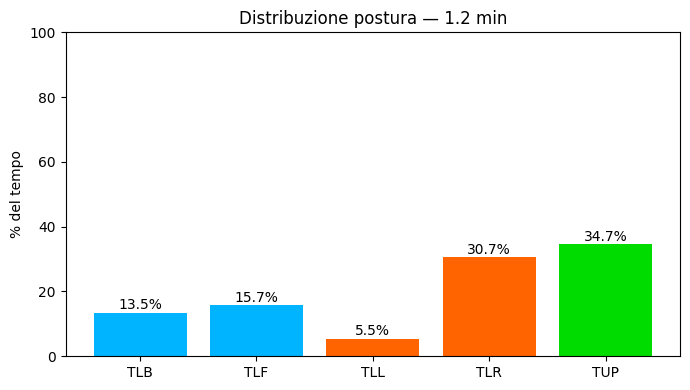


✓ Grafico salvato in: Test/report_sessione.png
✓ Log salvato: Test/monitor_20260322_121542.json


In [43]:
# ════════════════════════════════════════════════════════════════════
# FASE 2 — LOOP CONTINUO
# ════════════════════════════════════════════════════════════════════
if baseline_stats is None:
    raise RuntimeError("Eseguire prima la Cell 65a (calibrazione).")

posture_buffer   = collections.deque(maxlen=ALERT_BUFFER_SIZE)
session_counts   = {cls: 0 for cls in label_encoder.classes_}
alert_active     = False
alert_label      = None
alert_start_time = None
bad_posture_secs = 0.0
total_frames     = 0
session_start    = time.time()
last_clf_time    = 0.0
loop_log         = []

current_label = "TUP"
current_conf  = 1.0
current_rule  = {
    "confidence_tier": "high",
    "reason":          [],
    "lateral_score":   None,
    "sagittal_score":  None,
}
last_lm = None

cv2.namedWindow(WINDOW_NAME, cv2.WINDOW_NORMAL)
cv2.resizeWindow(WINDOW_NAME, 1280, 720)

print("Monitoraggio attivo — premi Q sulla finestra per terminare.")
print(f"{'t':>7}  {'cambio':<14}  {'sag':>8}  {'lat':>8}  regola")
print("─" * 70)

try:
    while True:
        ret, frame = cap.read()
        if not ret or frame is None:
            break

        now = time.time()

        if now - last_clf_time >= 1.0 / CLASSIFICATION_FPS:
            last_clf_time = now
            try:
                res = pose.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            except Exception:
                res = None

            if res and res.pose_landmarks and check_visibility(res):
                last_lm = res.pose_landmarks.landmark
                lm_arr  = smooth_z(landmarks_to_array(res))
                fd, _   = extract_features_from_array(lm_arr, res)
                mv      = feature_dict_to_model_vector(fd, BEST_FEATURE_COLUMNS)

                if not np.all(~np.isfinite(mv)):
                    lml, conf, _ = predict(mv, best_model, label_encoder)
                    lf, rule     = classify_posture(lml, conf, fd, baseline_stats)

                    if lf != current_label:
                        sag    = rule.get("sagittal_score", "?")
                        lat    = rule.get("lateral_score",  "?")
                        reason = " | ".join(rule.get("reason", []))[:40]
                        t      = now - session_start
                        print(f"  {t:5.1f}s  "
                              f"{current_label} → {lf:<4}  "
                              f"sag={sag!s:>7}  lat={lat!s:>7}  {reason}")

                    current_label = lf
                    current_conf  = conf
                    current_rule  = rule

                    posture_buffer.append(lf)
                    session_counts[lf] = session_counts.get(lf, 0) + 1
                    total_frames += 1

                    loop_log.append({
                        "t":    round(now - session_start, 1),
                        "pred": lf,
                        "ml":   lml,
                        "conf": round(conf, 3),
                        "rule_triggered": rule.get("rule_triggered"),
                        "reason": " | ".join(rule.get("reason", [])),
                        "lat_score": rule.get("lateral_score"),
                        "sag_score": rule.get("sagittal_score"),
                        **{k: round(v, 4) if isinstance(v, float) and np.isfinite(v) else None
                           for k, v in fd.items()},
                    })

        if len(posture_buffer) == ALERT_BUFFER_SIZE:
            bad       = [l for l in posture_buffer if l != "TUP"]
            bad_ratio = len(bad) / ALERT_BUFFER_SIZE

            if bad_ratio >= ALERT_BAD_RATIO:
                if not alert_active:
                    alert_active     = True
                    alert_start_time = now
                    from collections import Counter
                    alert_label = Counter(bad).most_common(1)[0][0]
                    print(f"⚠  ALERT: {alert_label} — "
                          f"{LABEL_DESC.get(alert_label, '')} "
                          f"({bad_ratio*100:.0f}% ultimi 5s)")
            else:
                if alert_active:
                    bad_posture_secs += now - alert_start_time
                    print(f"✓  Postura corretta — alert off "
                          f"(scorretta finora: {bad_posture_secs:.0f}s)")
                alert_active = False
                alert_label  = None

        display = frame.copy()
        h, w    = display.shape[:2]
        color   = LABEL_COLORS.get(current_label, (255, 255, 255))
        desc    = LABEL_DESC.get(current_label, current_label)

        ov = display.copy()
        cv2.rectangle(ov, (0, 0), (w, 90), (10, 10, 10), -1)
        cv2.addWeighted(ov, 0.75, display, 0.25, 0, display)

        cv2.putText(display, f"{current_label}  {desc}",
                    (14, 42), cv2.FONT_HERSHEY_DUPLEX, 1.0,
                    (0, 0, 0), 4, cv2.LINE_AA)
        cv2.putText(display, f"{current_label}  {desc}",
                    (14, 42), cv2.FONT_HERSHEY_DUPLEX, 1.0,
                    color, 2, cv2.LINE_AA)
        cv2.putText(display, f"Conf: {current_conf:.1%}",
                    (14, 74), cv2.FONT_HERSHEY_DUPLEX, 0.55,
                    (0, 0, 0), 3, cv2.LINE_AA)
        cv2.putText(display, f"Conf: {current_conf:.1%}",
                    (14, 74), cv2.FONT_HERSHEY_DUPLEX, 0.55,
                    (180, 180, 180), 1, cv2.LINE_AA)

        bar_col = (0, 220, 0) if current_label == "TUP" else (0, 0, 255)
        cv2.rectangle(display, (w - 18, 0), (w, h), bar_col, -1)

        if last_lm:
            for idx, col in [(2,  (255, 220, 0)),
                             (5,  (255, 220, 0)),
                             (11, (0, 220, 0)),
                             (12, (0, 220, 0)),
                             (0,  (255, 255, 255))]:
                px = int(last_lm[idx].x * w)
                py = int(last_lm[idx].y * h)
                cv2.circle(display, (px, py), 6, col, -1)
                cv2.circle(display, (px, py), 8, (255, 255, 255), 1)

        if current_rule:
            sag      = current_rule.get("sagittal_score", "?")
            lat      = current_rule.get("lateral_score",  "?")
            rule_str = " | ".join(current_rule.get("reason", []))[:60]
            cv2.putText(display, f"sag: {sag}   lat: {lat}",
                        (10, h - 22), cv2.FONT_HERSHEY_SIMPLEX, 0.40,
                        (0, 0, 0), 2, cv2.LINE_AA)
            cv2.putText(display, f"sag: {sag}   lat: {lat}",
                        (10, h - 22), cv2.FONT_HERSHEY_SIMPLEX, 0.40,
                        (180, 255, 180), 1, cv2.LINE_AA)
            cv2.putText(display, rule_str,
                        (10, h - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.40,
                        (0, 0, 0), 2, cv2.LINE_AA)
            cv2.putText(display, rule_str,
                        (10, h - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.40,
                        (180, 255, 180), 1, cv2.LINE_AA)

        cv2.imshow(WINDOW_NAME, display)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("Monitoraggio terminato.")
            cv2.destroyAllWindows()
            cv2.waitKey(1)
            break

finally:
    cv2.destroyAllWindows()
    cv2.waitKey(1)
    if alert_active and alert_start_time:
        bad_posture_secs += time.time() - alert_start_time

# ════════════════════════════════════════════════════════════════════
# REPORT FINALE
# ════════════════════════════════════════════════════════════════════
total_time = time.time() - session_start
good_time  = max(0.0, total_time - bad_posture_secs)

print("\n" + "═" * 60)
print("REPORT SESSIONE")
print("═" * 60)
print(f"  Durata totale:       {total_time/60:.1f} min ({total_time:.0f}s)")
print(f"  Postura corretta:    {good_time:.0f}s  ({good_time/total_time*100:.1f}%)")
print(f"  Postura scorretta:   {bad_posture_secs:.0f}s  "
      f"({bad_posture_secs/total_time*100:.1f}%)")
print(f"  Campioni totali:     {total_frames}")

if total_frames > 0:
    print("\n  Distribuzione classi:")
    for cls in sorted(session_counts):
        cnt = session_counts[cls]
        if cnt > 0:
            pct = cnt / total_frames * 100
            bar = "█" * int(pct / 3)
            print(f"    {cls}  {LABEL_DESC.get(cls, cls):<30} {pct:5.1f}%  {bar}")

if total_frames > 0:
    labels_plot = [c for c in sorted(session_counts) if session_counts[c] > 0]
    values_plot = [session_counts[c] / total_frames * 100 for c in labels_plot]
    colors_plot = [
        (0/255, 220/255, 0/255)   if l == "TUP" else
        (255/255, 100/255, 0/255) if l in ("TLL", "TLR") else
        (0/255, 180/255, 255/255)
        for l in labels_plot
    ]
    plt.figure(figsize=(7, 4))
    plt.bar(labels_plot, values_plot, color=colors_plot)
    plt.ylabel("% del tempo")
    plt.title(f"Distribuzione postura — {total_time/60:.1f} min")
    plt.ylim(0, 100)
    for i, v in enumerate(values_plot):
        plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(TEST_DIR, "report_sessione.png"), dpi=150)
    plt.show()
    print(f"\n✓ Grafico salvato in: {TEST_DIR}/report_sessione.png")

log_path = os.path.join(
    TEST_DIR, f"monitor_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
)
with open(log_path, "w") as f:
    json.dump({
        "total_seconds":     round(total_time, 1),
        "good_seconds":      round(good_time, 1),
        "bad_seconds":       round(bad_posture_secs, 1),
        "total_frames":      total_frames,
        "class_counts":      session_counts,
        "alert_threshold_s": ALERT_SECONDS,
        "log":               loop_log,
    }, f, indent=2)
print(f"✓ Log salvato: {log_path}")

## Chiusura connessione

In [ ]:
cap.release()
cv2.destroyAllWindows()
print("Connessione chiusa.")

Connessione chiusa.
